# Texto — benchmark melhorado Ollama/Qwen para reconhecimento de emoções

Este notebook é a versão melhorada para escolher a melhor estratégia de classificação emocional em **texto transcrito**.

Decisões desta versão:

1. O foco passa a ser **qualidade**, não velocidade.
2. O benchmark compara por defeito `qwen2.5:3b-instruct` com um modelo maior, `qwen2.5:7b-instruct`, via Ollama.
3. O dataset textual passa de **200 para 250 relatos**:
   - os primeiros 200 mantêm o conjunto base;
   - os últimos 50 (`AMB001`–`AMB050`) são relatos mais realistas e ambíguos, próximos de transcrições de 30–60 segundos sobre “como foi o dia”.
4. Cada estratégia continua a devolver uma **distribuição probabilística** pelas 7 classes: `joy`, `sadness`, `surprise`, `anger`, `disgust`, `fear`, `neutral`.
5. O notebook guarda os resultados, compara desempenho por modelo/estratégia e separa métricas para exemplos limpos vs ambíguos.
6. A função final de produção usa automaticamente a melhor combinação `modelo + estratégia` encontrada no benchmark.


In [1]:
# ============================================================
# 1. Imports e configuração
# ============================================================

import os
import re
import json
import time
import hashlib
import warnings
from pathlib import Path
from typing import Dict, List, Callable, Optional, Tuple

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

EMOTIONS = ["joy", "sadness", "surprise", "anger", "disgust", "fear", "neutral"]

# Foco qualidade:
# - Mantém o 3B como baseline para comparação.
# - Usa o 7B como modelo maior recomendado.
# Podes alterar sem mexer no código:
#   export OLLAMA_MODELS="qwen2.5:3b-instruct,qwen2.5:7b-instruct"
BASELINE_TEXT_MODEL = os.environ.get("OLLAMA_BASELINE_MODEL", "qwen2.5:3b-instruct")
PRIMARY_TEXT_MODEL = os.environ.get("OLLAMA_PRIMARY_MODEL", "qwen2.5:7b-instruct")

_model_env = os.environ.get("OLLAMA_MODELS", f"{BASELINE_TEXT_MODEL},{PRIMARY_TEXT_MODEL}")
TEXT_MODELS = []
for _m in [m.strip() for m in _model_env.split(",") if m.strip()]:
    if _m not in TEXT_MODELS:
        TEXT_MODELS.append(_m)

# Compatibilidade com funções antigas: TEXT_MODEL representa o modelo principal.
TEXT_MODEL = PRIMARY_TEXT_MODEL

OLLAMA_HOST = os.environ.get("OLLAMA_HOST", "http://localhost:11434")
OUTPUT_DIR = Path("ollama_text_outputs_v2_250_quality")
OUTPUT_DIR.mkdir(exist_ok=True)
CACHE_PATH = OUTPUT_DIR / "ollama_cache.json"

print(f"✅ Modelos textuais a testar: {TEXT_MODELS}")
print(f"✅ Modelo principal para produção: {TEXT_MODEL}")
print(f"✅ Ollama host: {OLLAMA_HOST}")
print(f"✅ Outputs: {OUTPUT_DIR.resolve()}")


✅ Modelos textuais a testar: ['qwen2.5:3b-instruct', 'qwen2.5:7b-instruct']
✅ Modelo principal para produção: qwen2.5:7b-instruct
✅ Ollama host: http://localhost:11434
✅ Outputs: /home/tomas/MIA/1ANO/2SEM/CA/CA-25_26/tests/text/ollama_text_outputs_v2_250_quality


In [2]:
# ============================================================
# 2. Dataset textual expandido para benchmark
# ============================================================
# Dataset com 250 relatos em português, anotados nas 7 classes emocionais.
# - 200 relatos base/limpos.
# - 50 relatos finais mais ambíguos e realistas, simulando relatos diários transcritos.
#
# Nota metodológica:
# - Estes exemplos continuam a ser um benchmark experimental.
# - Os últimos 50 foram adicionados para reduzir o risco de um dataset demasiado "limpo"
#   e testar melhor casos de mistura emocional.

dataset_200 = [
    {
        "id": "J001",
        "text": "Hoje foi um dia maravilhoso! Consegui finalmente terminar aquele projeto que me estava a dar tanto trabalho. A sensação de alívio e orgulho é indescritível. Saí do escritório com um sorriso e ainda fui celebrar com os colegas. Estou mesmo feliz!",
        "true_label": "joy"
    },
    {
        "id": "J002",
        "text": "A minha filha deu os primeiros passos hoje. Fiquei tão emocionado que até chorei de alegria. Ver o progresso dela, aquela determinação, foi uma das melhores coisas que já vi. Guardei tudo em vídeo para nunca esquecer.",
        "true_label": "joy"
    },
    {
        "id": "J003",
        "text": "Recebi uma promoção inesperada no trabalho. Nem sei o que dizer, estou radiante. Todo o esforço dos últimos anos valeu a pena. Liguei logo para a minha mãe a dar a notícia.",
        "true_label": "joy"
    },
    {
        "id": "J004",
        "text": "Passei a tarde com a minha melhor amiga que não via há meses. Rimos tanto, comemos bolachas caseiras e pusemos a conversa em dia. Saí de lá com o coração quentinho. Dias assim são raros e preciosos.",
        "true_label": "joy"
    },
    {
        "id": "J005",
        "text": "O meu time ganhou o campeonato. Vi o jogo com os amigos, todos a torcer juntos. Quando saiu o golo da vitória, abraçámo-nos todos, foi uma loucura. Ainda estamos a celebrar.",
        "true_label": "joy"
    },
    {
        "id": "J006",
        "text": "Consegui marcar aquela viagem que tanto queria. Já comprei os bilhetes, reservei o hotel. Sinto uma felicidade antecipada, parece que já estou lá de tão entusiasmada.",
        "true_label": "joy"
    },
    {
        "id": "S001",
        "text": "Acordei com o coração pesado. Sinto falta dele. Tudo me lembra os momentos que passámos juntos. O quarto parece vazio, a casa está silenciosa demais. Não sei quando isto vai passar.",
        "true_label": "sadness"
    },
    {
        "id": "S002",
        "text": "Hoje foi o funeral do meu avô. Ver a minha avó tão desfeita partiu-me o coração. Lembrei-me de todas as histórias que ele me contava, das brincadeiras. Sinto um vazio enorme.",
        "true_label": "sadness"
    },
    {
        "id": "S003",
        "text": "Fui despedido do trabalho. Não estava à espera, pensei que ia ficar mais tempo. Agora tenho contas para pagar e não sei o que fazer. Sinto-me perdido e triste.",
        "true_label": "sadness"
    },
    {
        "id": "S004",
        "text": "Chorei sozinha no carro. Não sei explicar bem, é uma tristeza que vem do nada. Até ouvir a minha música favorita me soube a pouco. Dias assim são difíceis de aguentar.",
        "true_label": "sadness"
    },
    {
        "id": "S005",
        "text": "O meu cão já não se mexe quase. Está velhote, cheio de dores. Fiquei a fazer-lhe festas o dia todo, a lembrar os bons momentos. Sei que o fim está perto e doi tanto.",
        "true_label": "sadness"
    },
    {
        "id": "S006",
        "text": "Sinto que perdi o prazer nas coisas. Antes adorava ler, sair, dançar. Agora tudo me parece cinzento. Acordo sem vontade, durmo sem descansar. É um cansaço da alma.",
        "true_label": "sadness"
    },
    {
        "id": "U001",
        "text": "Não estava nada à espera! A minha irmã apareceu de surpresa em minha casa. Ela vive no estrangeiro e não dizia nada. Quando abri a porta, fiquei em choque, nem conseguia falar. Foi a melhor surpresa do ano!",
        "true_label": "surprise"
    },
    {
        "id": "U002",
        "text": "Ganhei um prémio no sorteio da empresa. Nem sabia que tinha participado, foi um colega que me inscreveu. Quando anunciaram o meu nome, quase caí da cadeira. Ainda estou a processar.",
        "true_label": "surprise"
    },
    {
        "id": "U003",
        "text": "Descobri que vou ser pai. O teste deu positivo e eu nem sabia o que dizer. Fiquei parado a olhar para o teste, a tentar perceber se era real. Não estava nos planos, mas agora é.",
        "true_label": "surprise"
    },
    {
        "id": "U004",
        "text": "Estava no supermercado quando ouvi a minha música favorita na rádio. A que tocou no meu casamento, que já não ouvia há anos. Parei no meio do corredor, fiquei paralisada. Nem acreditei.",
        "true_label": "surprise"
    },
    {
        "id": "U005",
        "text": "Recebi uma carta de uma pessoa que não via há dez anos. Dizia que se lembrava de mim com carinho e queria reatar contacto. Fiquei sem reação, tive que ler três vezes.",
        "true_label": "surprise"
    },
    {
        "id": "U006",
        "text": "O médico disse que os meus exames estão ótimos. Estava tão nervosa à espera, pensei logo no pior. Quando ele disse 'está tudo bem', nem conseguia falar. Foi um alívio tão grande que quase chorei.",
        "true_label": "surprise"
    },
    {
        "id": "A001",
        "text": "Estou mesmo furioso! Alguém arranhou o meu carro no estacionamento e fugiu sem deixar nada. Vou ter que pagar do meu bolso um arranjo caríssimo. É uma falta de respeito e de civismo.",
        "true_label": "anger"
    },
    {
        "id": "A002",
        "text": "O meu colega roubou a ideia do meu projeto. Apresentou-a como se fosse dele. Quando o confrontei, ainda disse que eu estava a exagerar. Nunca me senti tão traído e revoltado.",
        "true_label": "anger"
    },
    {
        "id": "A003",
        "text": "Fiquei uma hora à espera no atendimento ao cliente. Quando finalmente atenderam, desligaram-me na cara. Voltei a ligar e disseram que não podiam fazer nada. É de uma incompetência incrível!",
        "true_label": "anger"
    },
    {
        "id": "A004",
        "text": "O vizinho de cima pôs música alta às três da manhã. Já pedi para baixar, já chamei a polícia, ele não quer saber. Não consigo dormir, estou a ficar louco com isto.",
        "true_label": "anger"
    },
    {
        "id": "A005",
        "text": "Prometeram-me um aumento há seis meses e nada. Cada vez que pergunto, inventam uma desculpa. Sinto-me enganado e desvalorizado. Estou a pensar em sair da empresa.",
        "true_label": "anger"
    },
    {
        "id": "A006",
        "text": "A encomenda que fiz chegou com duas semanas de atraso. Quando abri, vinha trocada e partida. Reclamei e disseram que não podiam fazer nada. Nunca mais compro nesta loja.",
        "true_label": "anger"
    },
    {
        "id": "D001",
        "text": "Vi um homem a cuspir no chão do supermercado. No meio dos alimentos, com pessoas à volta. Que nojo, uma pessoa daquelas não tem educação nenhuma. Fiquei mesmo enojado.",
        "true_label": "disgust"
    },
    {
        "id": "D002",
        "text": "Abri o leite e estava coalhado. O cheiro era nauseabundo, quase vomitei. A validade ainda não tinha passado. Nunca mais compro daquela marca.",
        "true_label": "disgust"
    },
    {
        "id": "D003",
        "text": "O funcionário da loja foi tão mal-educado. Atendeu-me de má vontade, revirou os olhos quando fiz uma pergunta. Senti tanto nojo daquela atitude que saí sem comprar nada.",
        "true_label": "disgust"
    },
    {
        "id": "D004",
        "text": "No metro, um homem ao meu lado começou a comer algo com as mãos e a lamber os dedos. Fazia barulho nojento, baba. Tive que me trocar de lugar, não aguentei.",
        "true_label": "disgust"
    },
    {
        "id": "D005",
        "text": "Li uma notícia sobre corrupção política. Desviavam dinheiro dos hospitais. Enquanto pessoas morrem à espera, eles enchiam os bolsos. A repulsa que sinto é indescritível.",
        "true_label": "disgust"
    },
    {
        "id": "F001",
        "text": "Recebi uma mensagem ameaçadora no telemóvel. Alguém que sabe onde vivo e onde trabalho. Passei a noite sem dormir, com medo de ouvir algum barulho. Não sei o que fazer.",
        "true_label": "fear"
    },
    {
        "id": "F002",
        "text": "Tive que fazer uma apresentação para a direção. As mãos tremiam, a voz falhava. Senti um aperto no peito, pensei que ia desmaiar. Detesto falar em público.",
        "true_label": "fear"
    },
    {
        "id": "F003",
        "text": "Ouvi passos atrás de mim na rua deserta. Acelerei o passo, os passos também aceleraram. Entrei no primeiro café que vi. Nunca tive tanto medo.",
        "true_label": "fear"
    },
    {
        "id": "F004",
        "text": "Sonhei que me perseguiam. Acordei às três da manhã aos gritos, encharcada em suor. Não consegui voltar a dormir, fiquei com os olhos abertos no escuro.",
        "true_label": "fear"
    },
    {
        "id": "F005",
        "text": "O médico pediu exames urgentes. Disse que podia ser algo grave. Estou há dias sem conseguir pensar noutra coisa, o coração acelera só de imaginar.",
        "true_label": "fear"
    },
    {
        "id": "F006",
        "text": "A minha empresa está a despedir pessoas. Ninguém sabe quem vai sair. Cada vez que o telemóvel toca, o meu coração dispara. Vivo com um nó no estômago.",
        "true_label": "fear"
    },
    {
        "id": "N001",
        "text": "Hoje foi um dia normal. Fui trabalhar, almocei, voltei para casa. Não aconteceu nada de especial. Uma quarta-feira como outra qualquer.",
        "true_label": "neutral"
    },
    {
        "id": "N002",
        "text": "Passei o dia a fazer limpezas. Aspirei, lavei a loiça, arrumei os armários. À noite vi televisão e fui dormir. Rotina habitual.",
        "true_label": "neutral"
    },
    {
        "id": "N003",
        "text": "Resolvi umas papeladas do banco, atualizei o cartão de cidadão. Esperei nas filas, preenchi formulários. Depois vim para casa, jantei e li um bocado.",
        "true_label": "neutral"
    },
    {
        "id": "N004",
        "text": "Hoje fui ao ginásio como faço sempre. Fiz o treino habitual, tomei banho, vim embora. O trânsito estava normal. Mais um dia igual.",
        "true_label": "neutral"
    },
    {
        "id": "N005",
        "text": "Atendi vários clientes no trabalho. Reuniões de rotina, emails, relatórios. Nada de especial, apenas mais um dia de escritório.",
        "true_label": "neutral"
    },
    {
        "id": "J007",
        "text": "Hoje acordei cheio de energia e tudo parecia correr bem. O sol entrou pela janela, tomei um bom pequeno-almoço e consegui resolver várias tarefas que estavam pendentes. Acabei o dia com uma sensação genuína de satisfação.",
        "true_label": "joy"
    },
    {
        "id": "J008",
        "text": "Recebi uma mensagem de agradecimento de uma pessoa que ajudei há meses. Não estava à espera de ter feito tanta diferença. Fiquei comovido e muito contente por perceber que o meu esforço teve impacto.",
        "true_label": "joy"
    },
    {
        "id": "J009",
        "text": "Fui correr ao fim da tarde e bati o meu melhor tempo. Cheguei a casa cansado, mas com uma alegria enorme por sentir que estou a evoluir. Foi daqueles dias em que me senti capaz de tudo.",
        "true_label": "joy"
    },
    {
        "id": "J010",
        "text": "Hoje jantei com amigos antigos e parecia que o tempo não tinha passado. Rimos de histórias antigas, fizemos planos novos e saí de lá com uma leveza enorme. Senti-me mesmo feliz por ainda ter estas pessoas na minha vida.",
        "true_label": "joy"
    },
    {
        "id": "J011",
        "text": "A apresentação correu melhor do que eu imaginava. No fim, várias pessoas vieram dar-me os parabéns e elogiar a clareza do trabalho. Senti orgulho e uma alegria tranquila, como se todo o esforço tivesse valido a pena.",
        "true_label": "joy"
    },
    {
        "id": "J012",
        "text": "Passei a tarde a cozinhar com a minha mãe. Fizemos uma receita antiga da família e a casa ficou cheia daquele cheiro bom. Foi simples, mas senti uma felicidade muito grande nesses pequenos momentos.",
        "true_label": "joy"
    },
    {
        "id": "J013",
        "text": "Hoje comprei finalmente o livro que queria há meses. Sentei-me num café, pedi um galão e comecei a ler sem pressa. Foi uma alegria calma, daquelas que fazem o dia parecer melhor.",
        "true_label": "joy"
    },
    {
        "id": "J014",
        "text": "Consegui entregar tudo antes do prazo. Fechei o computador e senti um alívio tão bom que até fui dar uma volta só para celebrar. Foi um dia produtivo e fiquei muito satisfeito comigo.",
        "true_label": "joy"
    },
    {
        "id": "J015",
        "text": "O meu irmão ligou-me para dizer que foi aceite no curso que queria. Fiquei genuinamente feliz por ele, quase como se a conquista também fosse minha. Passámos a noite a celebrar em família.",
        "true_label": "joy"
    },
    {
        "id": "J016",
        "text": "Hoje recebi uma boa avaliação do meu orientador. Disse que o trabalho estava mais maduro e bem encaminhado. Saí da reunião com confiança e uma alegria enorme por sentir que estou no caminho certo.",
        "true_label": "joy"
    },
    {
        "id": "J017",
        "text": "Fui visitar a minha avó e ela estava muito bem-disposta. Contou piadas, mostrou fotografias antigas e fez questão de me dar um abraço apertado. Voltei para casa com o coração cheio.",
        "true_label": "joy"
    },
    {
        "id": "J018",
        "text": "Depois de semanas a treinar, consegui finalmente fazer aquele exercício sem ajuda. Parece pequeno, mas para mim foi uma vitória. Fiquei orgulhoso e feliz com o meu progresso.",
        "true_label": "joy"
    },
    {
        "id": "J019",
        "text": "Hoje ouvi uma música que adoro enquanto voltava para casa. Dei por mim a sorrir sozinho no autocarro. Foi um momento simples, mas deixou-me animado para o resto do dia.",
        "true_label": "joy"
    },
    {
        "id": "J020",
        "text": "Recebi a confirmação de que vou poder participar no projeto que queria. Estava à espera desta oportunidade há muito tempo. Sinto entusiasmo, gratidão e muita vontade de começar.",
        "true_label": "joy"
    },
    {
        "id": "J021",
        "text": "Passei o dia na praia com a família. A água estava boa, o tempo estava perfeito e ninguém teve pressa de ir embora. Foi um daqueles dias leves que ficam guardados na memória.",
        "true_label": "joy"
    },
    {
        "id": "J022",
        "text": "Hoje uma criança na rua sorriu para mim e ofereceu-me uma flor pequena. Foi um gesto tão inesperado e bonito que fiquei o resto do dia bem-disposto. Às vezes a felicidade aparece em detalhes mínimos.",
        "true_label": "joy"
    },
    {
        "id": "J023",
        "text": "O professor elogiou publicamente o nosso trabalho. Fiquei envergonhado, mas muito contente. Senti que todo o esforço do grupo foi finalmente reconhecido.",
        "true_label": "joy"
    },
    {
        "id": "J024",
        "text": "Voltei a tocar guitarra depois de muito tempo. Não saiu perfeito, mas senti uma alegria enorme por recuperar algo que me fazia bem. Perdi a noção do tempo enquanto tocava.",
        "true_label": "joy"
    },
    {
        "id": "J025",
        "text": "Hoje fiz as pazes com uma pessoa importante. Conversámos com calma, pedimos desculpa e acabámos a rir. Senti um alívio bom e uma felicidade serena.",
        "true_label": "joy"
    },
    {
        "id": "J026",
        "text": "A minha equipa conseguiu terminar uma fase complicada do projeto. No fim, ficámos todos a celebrar no chat, cansados mas contentes. Senti orgulho no que construímos juntos.",
        "true_label": "joy"
    },
    {
        "id": "J027",
        "text": "Fui ao parque ao fim da tarde e fiquei sentado a ver o pôr do sol. Não aconteceu nada de extraordinário, mas senti uma paz tão boa que quase parecia felicidade pura.",
        "true_label": "joy"
    },
    {
        "id": "J028",
        "text": "Hoje disseram-me que melhorei muito desde o início do semestre. Fiquei mesmo contente, porque às vezes não noto a minha própria evolução. Foi bom sentir reconhecimento.",
        "true_label": "joy"
    },
    {
        "id": "J029",
        "text": "Cheguei a casa e tinha um jantar surpresa preparado. Velas, música calma e comida de que gosto. Senti-me amado e profundamente feliz naquele momento.",
        "true_label": "joy"
    },
    {
        "id": "S007",
        "text": "Hoje acordei sem vontade de falar com ninguém. Tentei fazer as coisas normais, mas tudo parecia pesado. Acabei o dia deitado no sofá, com uma tristeza silenciosa que não consegui explicar.",
        "true_label": "sadness"
    },
    {
        "id": "S008",
        "text": "Passei em frente à antiga casa onde vivi com a minha família. As janelas estavam fechadas e o jardim abandonado. Senti uma saudade enorme de um tempo que já não volta.",
        "true_label": "sadness"
    },
    {
        "id": "S009",
        "text": "Recebi uma fotografia antiga do meu pai. Fiquei a olhar para ela durante muito tempo, lembrando a voz dele e as conversas que já não podemos ter. Doeu mais do que eu esperava.",
        "true_label": "sadness"
    },
    {
        "id": "S010",
        "text": "Hoje senti-me excluído no grupo. Todos combinaram planos e eu só soube depois. Tentei fingir que não me afetou, mas fiquei triste e com a sensação de não pertencer.",
        "true_label": "sadness"
    },
    {
        "id": "S011",
        "text": "A chuva caiu o dia inteiro e pareceu combinar com o meu estado de espírito. Trabalhei em silêncio, sem entusiasmo, e voltei para casa com um vazio difícil de disfarçar.",
        "true_label": "sadness"
    },
    {
        "id": "S012",
        "text": "Perdi um objeto que era muito importante para mim. Não tinha grande valor material, mas estava cheio de memórias. Passei o dia a procurá-lo e terminei com uma sensação amarga de perda.",
        "true_label": "sadness"
    },
    {
        "id": "S013",
        "text": "Hoje percebi que uma amizade está a afastar-se. As mensagens são cada vez mais curtas e os encontros já não acontecem. Sinto uma tristeza calma, como quem vê algo acabar devagar.",
        "true_label": "sadness"
    },
    {
        "id": "S014",
        "text": "Fui visitar o meu cão ao veterinário e ele parecia cansado e frágil. Tentei sorrir para o animar, mas por dentro estava desfeito. Custa muito ver quem gostamos sofrer.",
        "true_label": "sadness"
    },
    {
        "id": "S015",
        "text": "O dia passou sem nada correr especialmente mal, mas senti-me sozinho do início ao fim. Mesmo rodeado de pessoas, parecia que ninguém reparava em mim. Foi uma solidão pesada.",
        "true_label": "sadness"
    },
    {
        "id": "S016",
        "text": "Hoje falhei num objetivo que queria muito alcançar. Sei que posso tentar outra vez, mas neste momento só sinto desânimo. Fiquei a pensar que talvez não seja tão capaz como imaginava.",
        "true_label": "sadness"
    },
    {
        "id": "S017",
        "text": "Encontrei uma carta antiga guardada numa gaveta. Era de alguém que já não faz parte da minha vida. Li tudo devagar e terminei com lágrimas nos olhos.",
        "true_label": "sadness"
    },
    {
        "id": "S018",
        "text": "A minha irmã foi embora para outra cidade. Despedi-me dela na estação e tentei parecer forte, mas assim que o comboio arrancou senti uma tristeza enorme. A casa vai ficar diferente sem ela.",
        "true_label": "sadness"
    },
    {
        "id": "S019",
        "text": "Hoje vi fotografias de uma viagem que fiz há anos. Na altura parecia que tudo era simples e feliz. Agora senti uma saudade profunda, quase como se estivesse a perder outra vez aquele momento.",
        "true_label": "sadness"
    },
    {
        "id": "S020",
        "text": "Não consegui concentrar-me em nada. Tinha trabalho para fazer, mas a cabeça estava longe. Passei o dia com uma tristeza baixa e constante, como uma nuvem por cima de tudo.",
        "true_label": "sadness"
    },
    {
        "id": "S021",
        "text": "Recebi uma resposta fria de uma pessoa de quem gosto. Talvez não tenha sido por mal, mas magoou-me. Fiquei o resto do dia a repetir a conversa na cabeça.",
        "true_label": "sadness"
    },
    {
        "id": "S022",
        "text": "Hoje senti falta de casa. Mesmo estando no sítio onde vivo, deu-me uma nostalgia estranha da minha infância, das rotinas antigas e das pessoas que já mudaram. Foi um dia melancólico.",
        "true_label": "sadness"
    },
    {
        "id": "S023",
        "text": "Fui ao aniversário de alguém, mas não consegui entrar no ambiente. Via toda a gente feliz e eu sentia-me deslocado. Voltei cedo para casa com uma tristeza difícil de explicar.",
        "true_label": "sadness"
    },
    {
        "id": "S024",
        "text": "Hoje tive de aceitar que uma coisa pela qual lutei muito não vai acontecer. Ainda não sei lidar com isso. Sinto uma espécie de luto por uma possibilidade que desapareceu.",
        "true_label": "sadness"
    },
    {
        "id": "S025",
        "text": "Passei a tarde a arrumar o quarto e encontrei lembranças de uma relação antiga. Pensei que já estava ultrapassado, mas doeu. Há memórias que continuam a pesar.",
        "true_label": "sadness"
    },
    {
        "id": "S026",
        "text": "Hoje senti que estou a ficar para trás. Vejo os outros a avançar, a conseguir coisas, e eu aqui parado. Sei que comparar não ajuda, mas fiquei muito em baixo.",
        "true_label": "sadness"
    },
    {
        "id": "S027",
        "text": "A minha mãe parecia triste ao telefone e eu não consegui estar com ela. Fiquei com culpa e uma sensação de impotência. O resto do dia perdeu a cor.",
        "true_label": "sadness"
    },
    {
        "id": "S028",
        "text": "O jantar em família foi mais silencioso do que o habitual. Faltava uma pessoa à mesa e toda a gente parecia sentir isso. A ausência ocupou mais espaço do que qualquer conversa.",
        "true_label": "sadness"
    },
    {
        "id": "S029",
        "text": "Hoje fui dormir com a sensação de que dei tudo e mesmo assim não chegou. Não é raiva, é só tristeza e cansaço. Espero que amanhã pese menos.",
        "true_label": "sadness"
    },
    {
        "id": "U007",
        "text": "Hoje encontrei um colega de infância no comboio. Não o via há mais de quinze anos e reconhecemo-nos ao mesmo tempo. Fiquei tão surpreendido que nem sabia por onde começar a conversa.",
        "true_label": "surprise"
    },
    {
        "id": "U008",
        "text": "Abriram a porta da sala e todos gritaram o meu nome. Tinham preparado uma festa surpresa sem eu desconfiar de nada. Fiquei parado, de boca aberta, a tentar perceber como conseguiram esconder aquilo.",
        "true_label": "surprise"
    },
    {
        "id": "U009",
        "text": "Recebi um email a dizer que o meu texto foi selecionado para publicação. Eu tinha enviado quase sem esperança. Quando li a mensagem, tive de confirmar várias vezes se era mesmo para mim.",
        "true_label": "surprise"
    },
    {
        "id": "U010",
        "text": "Hoje descobri que uma pessoa que eu conheço trabalha afinal no mesmo edifício que eu. Cruzámo-nos no elevador e ficámos os dois espantados. O mundo às vezes parece demasiado pequeno.",
        "true_label": "surprise"
    },
    {
        "id": "U011",
        "text": "Fui abrir uma caixa antiga da garagem e encontrei fotografias que pensava perdidas. Não estava nada à espera. Passei vários minutos a olhar para aquilo completamente surpreendido.",
        "true_label": "surprise"
    },
    {
        "id": "U012",
        "text": "O autocarro mudou de percurso sem aviso e acabou por me deixar mesmo à porta do sítio onde eu precisava de ir. Foi tão inesperado que até me ri sozinho. Nunca pensei que um atraso me ajudasse.",
        "true_label": "surprise"
    },
    {
        "id": "U013",
        "text": "Hoje o meu professor chamou-me depois da aula e disse que queria indicar-me para uma bolsa. Fiquei sem palavras. Não fazia ideia de que ele tinha reparado tanto no meu trabalho.",
        "true_label": "surprise"
    },
    {
        "id": "U014",
        "text": "Recebi uma chamada de um número desconhecido e era uma rádio a dizer que eu tinha ganho bilhetes para um concerto. Pensei que fosse brincadeira. Fiquei completamente surpreendido.",
        "true_label": "surprise"
    },
    {
        "id": "U015",
        "text": "A luz foi abaixo em casa e, quando voltou, apareceu uma mensagem de aniversário no ecrã da televisão. A minha família tinha preparado tudo. Não esperava mesmo aquela criatividade.",
        "true_label": "surprise"
    },
    {
        "id": "U016",
        "text": "Hoje fui pagar o café e disseram-me que alguém já tinha pago por mim. Olhei à volta sem perceber quem tinha sido. Foi uma surpresa pequena, mas deixou-me intrigado o dia inteiro.",
        "true_label": "surprise"
    },
    {
        "id": "U017",
        "text": "O meu melhor amigo apareceu no meu local de trabalho com uma mochila e disse que tínhamos uma viagem marcada para o fim de semana. Fiquei sem reação. Nunca pensei que ele fosse capaz de organizar tudo sozinho.",
        "true_label": "surprise"
    },
    {
        "id": "U018",
        "text": "Encontrei dinheiro dentro de um casaco que não usava há meses. Não era muito, mas foi tão inesperado que pareceu um presente do passado. Fiquei surpreendido e divertido.",
        "true_label": "surprise"
    },
    {
        "id": "U019",
        "text": "Hoje vi o resultado de um exame e tinha uma nota muito superior ao que esperava. Fiquei a olhar para o ecrã sem acreditar. Pensei até que podia haver engano.",
        "true_label": "surprise"
    },
    {
        "id": "U020",
        "text": "A minha cadela aprendeu sozinha a abrir a porta da cozinha. Entrei e vi-a sentada no meio da sala como se nada fosse. Fiquei tão surpreendido que comecei a rir.",
        "true_label": "surprise"
    },
    {
        "id": "U021",
        "text": "Recebi uma encomenda que pensava perdida há semanas. Já tinha desistido dela. Quando o carteiro apareceu, fiquei mesmo espantado por ainda ter chegado.",
        "true_label": "surprise"
    },
    {
        "id": "U022",
        "text": "Hoje disseram-me que vou trabalhar com uma pessoa que admiro muito. Não estava nos planos e ninguém me tinha avisado. Fiquei surpreendido e nervoso ao mesmo tempo.",
        "true_label": "surprise"
    },
    {
        "id": "U023",
        "text": "Ao abrir o telemóvel, vi uma mensagem de alguém com quem não falava desde a escola. Era simpática e inesperada. Fiquei alguns minutos sem saber o que responder.",
        "true_label": "surprise"
    },
    {
        "id": "U024",
        "text": "Fui ao restaurante habitual e tinham mudado completamente o espaço durante a noite. Parecia outro sítio. Fiquei surpreendido ao entrar, como se tivesse errado na porta.",
        "true_label": "surprise"
    },
    {
        "id": "U025",
        "text": "Hoje descobri que o meu avô guardava desenhos meus de quando eu era pequeno. Estavam todos numa pasta, com datas. Fiquei muito surpreendido e emocionado.",
        "true_label": "surprise"
    },
    {
        "id": "U026",
        "text": "O meu chefe anunciou uma folga extra para toda a equipa. Ninguém estava à espera. A sala ficou em silêncio durante uns segundos antes de todos começarem a reagir.",
        "true_label": "surprise"
    },
    {
        "id": "U027",
        "text": "Estava a estudar na biblioteca quando encontrei uma dedicatória escrita num livro antigo com o meu apelido. Não sei se é família, mas fiquei completamente intrigado.",
        "true_label": "surprise"
    },
    {
        "id": "U028",
        "text": "Hoje a minha irmã revelou que vai casar. Guardou segredo durante semanas. Quando mostrou o anel, fiquei tão surpreendido que só consegui abraçá-la.",
        "true_label": "surprise"
    },
    {
        "id": "A007",
        "text": "Hoje fiquei mesmo irritado no trânsito. Um condutor quase bateu no meu carro porque decidiu mudar de faixa sem pisca. Ainda teve a lata de me insultar. Cheguei ao destino furioso.",
        "true_label": "anger"
    },
    {
        "id": "A008",
        "text": "Passei horas a preparar um ficheiro e alguém apagou tudo da pasta partilhada. Ninguém assume a responsabilidade. Sinto uma raiva enorme por tanta falta de cuidado.",
        "true_label": "anger"
    },
    {
        "id": "A009",
        "text": "No trabalho voltaram a pedir-me uma tarefa em cima da hora, como se eu não tivesse vida. Avisei várias vezes que precisava de planeamento. Estou farto de resolver urgências causadas pelos outros.",
        "true_label": "anger"
    },
    {
        "id": "A010",
        "text": "Hoje fui mal atendido num serviço público. Falaram comigo como se eu estivesse a incomodar. Saí de lá revoltado, porque ninguém merece ser tratado com arrogância.",
        "true_label": "anger"
    },
    {
        "id": "A011",
        "text": "A operadora cobrou-me um valor que eu nunca autorizei. Liguei para reclamar e passaram-me de departamento em departamento. Fiquei completamente enervado com a falta de responsabilidade.",
        "true_label": "anger"
    },
    {
        "id": "A012",
        "text": "O meu colega chegou atrasado outra vez e eu tive de fazer a parte dele. Depois ainda recebeu elogios pelo trabalho final. Senti uma injustiça enorme e muita raiva.",
        "true_label": "anger"
    },
    {
        "id": "A013",
        "text": "Hoje alguém espalhou uma mentira sobre mim. Quando soube, fiquei a tremer de irritação. Não aceito que prejudiquem a minha reputação sem qualquer razão.",
        "true_label": "anger"
    },
    {
        "id": "A014",
        "text": "Comprei um produto novo e veio estragado. Voltei à loja e tentaram convencer-me de que a culpa era minha. Fiquei indignado com aquela tentativa de fugir à garantia.",
        "true_label": "anger"
    },
    {
        "id": "A015",
        "text": "A reunião foi um desastre porque ninguém tinha lido os documentos. Passei dias a preparar tudo e os outros apareceram sem saber nada. Senti-me desrespeitado e furioso.",
        "true_label": "anger"
    },
    {
        "id": "A016",
        "text": "Hoje um professor falou comigo de forma injusta à frente da turma. Podia ter corrigido o erro em privado. Fiquei humilhado e revoltado com aquela atitude.",
        "true_label": "anger"
    },
    {
        "id": "A017",
        "text": "Estavam a gozar com uma pessoa mais nova no autocarro e ninguém dizia nada. Fiquei tão irritado que tive de intervir. Não suporto ver esse tipo de abuso.",
        "true_label": "anger"
    },
    {
        "id": "A018",
        "text": "O senhorio prometeu arranjar a infiltração há meses e continua tudo igual. A parede está cada vez pior. Estou cansado de desculpas e sinto-me completamente enganado.",
        "true_label": "anger"
    },
    {
        "id": "A019",
        "text": "Hoje perdi uma manhã por causa de uma informação errada que me deram. Fui de um lado para o outro sem necessidade. Fiquei furioso com a incompetência do atendimento.",
        "true_label": "anger"
    },
    {
        "id": "A020",
        "text": "A minha encomenda foi marcada como entregue, mas nunca apareceu. O apoio ao cliente repetiu respostas automáticas sem resolver nada. Senti uma raiva enorme por estar a ser ignorado.",
        "true_label": "anger"
    },
    {
        "id": "A021",
        "text": "Estava numa fila há vinte minutos quando alguém passou à frente como se fosse normal. Quando reclamei, ainda me respondeu mal. Fiquei mesmo irritado com a falta de educação.",
        "true_label": "anger"
    },
    {
        "id": "A022",
        "text": "Hoje senti que aproveitaram a minha boa vontade. Pedi ajuda uma vez e ninguém apareceu, mas quando precisam de mim ligam logo. Estou revoltado e cansado dessa desigualdade.",
        "true_label": "anger"
    },
    {
        "id": "A023",
        "text": "O computador do laboratório estava avariado e ninguém avisou. Perdi tempo, deslocação e concentração. Fiquei irritado porque era uma coisa simples de comunicar.",
        "true_label": "anger"
    },
    {
        "id": "A024",
        "text": "Prometeram entregar o trabalho de grupo ontem e só enviaram ficheiros incompletos. Agora tenho de corrigir tudo sozinho. Estou mesmo zangado com esta irresponsabilidade.",
        "true_label": "anger"
    },
    {
        "id": "A025",
        "text": "Hoje um cliente gritou comigo por um problema que eu não causei. Mantive a calma, mas por dentro estava furioso. Não sou saco de pancada de ninguém.",
        "true_label": "anger"
    },
    {
        "id": "A026",
        "text": "A companhia cancelou o voo sem explicações claras. Deram-nos um voucher inútil e mandaram-nos esperar. Senti-me preso e revoltado com a forma como trataram todos.",
        "true_label": "anger"
    },
    {
        "id": "A027",
        "text": "Vi alguém deixar lixo no parque depois de fazer piquenique. Havia caixotes a poucos metros. Fiquei irritado com tanto desprezo pelo espaço comum.",
        "true_label": "anger"
    },
    {
        "id": "A028",
        "text": "Hoje descobri que mudaram as regras do trabalho sem avisar a equipa. Agora querem cobrar-nos erros que resultam dessa mudança. Estou indignado com esta falta de transparência.",
        "true_label": "anger"
    },
    {
        "id": "D006",
        "text": "Hoje entrei numa casa de banho pública completamente imunda. O cheiro era horrível e havia lixo espalhado pelo chão. Saí de lá imediatamente, cheio de nojo.",
        "true_label": "disgust"
    },
    {
        "id": "D007",
        "text": "Abri uma embalagem de carne e vinha com um cheiro azedo insuportável. A cor também estava estranha. Fiquei enojado e perdi logo a vontade de cozinhar.",
        "true_label": "disgust"
    },
    {
        "id": "D008",
        "text": "Vi uma pessoa a mexer em comida exposta com as mãos sujas e depois a deixá-la no sítio. Fiquei com tanta repulsa que saí da loja sem comprar nada.",
        "true_label": "disgust"
    },
    {
        "id": "D009",
        "text": "Hoje encontrei bolor dentro de uma garrafa que supostamente estava lavada. Só reparei quando já ia beber. Senti um arrepio de nojo e lavei tudo várias vezes.",
        "true_label": "disgust"
    },
    {
        "id": "D010",
        "text": "Ouvi comentários muito cruéis sobre uma pessoa que estava a passar dificuldades. A falta de empatia deixou-me profundamente enojado. Há atitudes que me dão verdadeira repulsa.",
        "true_label": "disgust"
    },
    {
        "id": "D011",
        "text": "No restaurante, o copo veio com marcas de batom de outra pessoa. Chamei o empregado e ele ainda pareceu incomodado. Fiquei enjoado só de pensar na falta de higiene.",
        "true_label": "disgust"
    },
    {
        "id": "D012",
        "text": "Hoje vi um vídeo de maus-tratos a animais que me deixou perturbado. Não consegui acabar de ver. Senti uma repulsa enorme por quem consegue fazer aquilo.",
        "true_label": "disgust"
    },
    {
        "id": "D013",
        "text": "Abri o frigorífico do escritório e havia comida estragada há semanas. O cheiro espalhou-se pela sala inteira. Foi nojento e ninguém queria sequer aproximar-se.",
        "true_label": "disgust"
    },
    {
        "id": "D014",
        "text": "Uma pessoa no autocarro tossiu repetidamente sem tapar a boca, mesmo em cima dos outros. Fiquei desconfortável e enojado com a falta de respeito básico.",
        "true_label": "disgust"
    },
    {
        "id": "D015",
        "text": "Hoje soube de um caso de fraude contra idosos. Enganaram pessoas vulneráveis para lhes tirar dinheiro. Fiquei com uma sensação de nojo moral, uma repulsa difícil de explicar.",
        "true_label": "disgust"
    },
    {
        "id": "D016",
        "text": "Peguei numa maçã que parecia boa, mas estava podre por baixo. Os dedos ficaram pegajosos e com mau cheiro. Deu-me uma volta ao estômago.",
        "true_label": "disgust"
    },
    {
        "id": "D017",
        "text": "O caixote do prédio ficou dias sem ser despejado e o cheiro no corredor era insuportável. Havia líquidos no chão. Cada vez que passava, sentia nojo.",
        "true_label": "disgust"
    },
    {
        "id": "D018",
        "text": "Hoje uma pessoa contou uma piada racista no grupo como se fosse normal. Fiquei calado por segundos, mas senti uma repulsa enorme. Há coisas que revelam muito mau caráter.",
        "true_label": "disgust"
    },
    {
        "id": "D019",
        "text": "No café, vi uma barata a passar perto do balcão dos bolos. Perdi completamente a vontade de comer. Saí de lá com uma sensação de nojo que não me largou.",
        "true_label": "disgust"
    },
    {
        "id": "D020",
        "text": "O pano usado para limpar a mesa estava sujo e cheirava mal. Em vez de limpar, espalhou gordura. Fiquei enojado e pedi para trocar de mesa.",
        "true_label": "disgust"
    },
    {
        "id": "D021",
        "text": "Hoje encontrei cabelo dentro da sopa. Sei que pode acontecer, mas foi impossível continuar a comer. Fiquei com náuseas e uma sensação horrível.",
        "true_label": "disgust"
    },
    {
        "id": "D022",
        "text": "Li mensagens de alguém a manipular outra pessoa de forma fria e calculista. Não foi só irritação; senti nojo daquela crueldade disfarçada de carinho.",
        "true_label": "disgust"
    },
    {
        "id": "D023",
        "text": "O balneário estava cheio de lama, toalhas molhadas e um cheiro intenso a suor antigo. Entrei e saí logo. Era impossível ficar ali.",
        "true_label": "disgust"
    },
    {
        "id": "D024",
        "text": "Hoje vi alguém atirar beatas para uma zona de jardim onde crianças brincam. A falta de cuidado com os outros deu-me repulsa.",
        "true_label": "disgust"
    },
    {
        "id": "D025",
        "text": "Comprei pão e, quando cheguei a casa, reparei que tinha bolor numa das fatias. A ideia de quase ter comido aquilo deixou-me enjoado.",
        "true_label": "disgust"
    },
    {
        "id": "D026",
        "text": "Uma pessoa falou de forma humilhante com o empregado do restaurante. Aquela superioridade arrogante deu-me nojo. Não consegui ignorar a cena.",
        "true_label": "disgust"
    },
    {
        "id": "D027",
        "text": "Hoje encontrei lixo alimentar dentro do elevador. O cheiro era tão forte que tive de subir pelas escadas. Fiquei enojado com a falta de civismo.",
        "true_label": "disgust"
    },
    {
        "id": "D028",
        "text": "Vi uma reportagem sobre condições degradantes numa instituição que devia cuidar de pessoas. Senti revolta, mas sobretudo repulsa pela negligência e pela falta de humanidade.",
        "true_label": "disgust"
    },
    {
        "id": "F007",
        "text": "Hoje o carro começou a fazer um barulho estranho na autoestrada. Senti o coração acelerar e agarrei o volante com força. Só queria chegar à berma em segurança.",
        "true_label": "fear"
    },
    {
        "id": "F008",
        "text": "Recebi uma chamada do hospital a pedir para ir lá com urgência. Não explicaram quase nada. Passei o caminho inteiro com medo do que me iam dizer.",
        "true_label": "fear"
    },
    {
        "id": "F009",
        "text": "Acordei com um barulho forte vindo da cozinha. Fiquei imóvel na cama, a tentar perceber se havia alguém em casa. Demorei muito até ganhar coragem para me levantar.",
        "true_label": "fear"
    },
    {
        "id": "F010",
        "text": "Hoje tive uma crise de ansiedade antes de sair. O peito apertou, as mãos suaram e parecia que algo terrível ia acontecer. Foi assustador, mesmo sabendo que talvez não houvesse perigo real.",
        "true_label": "fear"
    },
    {
        "id": "F011",
        "text": "Vi um cão grande solto a correr na minha direção. Não sabia se estava a brincar ou a atacar. Fiquei paralisado, cheio de medo, até o dono o chamar.",
        "true_label": "fear"
    },
    {
        "id": "F012",
        "text": "A minha mãe não atendia o telefone há horas, o que é muito estranho nela. Comecei a imaginar acidentes e problemas. Fiquei com um medo crescente até ela finalmente ligar de volta.",
        "true_label": "fear"
    },
    {
        "id": "F013",
        "text": "Hoje quase caí das escadas. Escorreguei e consegui agarrar-me ao corrimão no último segundo. Fiquei a tremer durante vários minutos.",
        "true_label": "fear"
    },
    {
        "id": "F014",
        "text": "Recebi um aviso de tentativa de acesso à minha conta bancária. Não fui eu. Fiquei assustado, mudei passwords e passei o resto do dia com receio de ter sido roubado.",
        "true_label": "fear"
    },
    {
        "id": "F015",
        "text": "O avião apanhou turbulência forte. As luzes tremeram e algumas pessoas gritaram. Tentei manter a calma, mas senti um medo enorme no estômago.",
        "true_label": "fear"
    },
    {
        "id": "F016",
        "text": "Hoje tive de passar por uma rua mal iluminada. Ouvi vozes atrás de mim e acelerei o passo. Estava sempre a olhar para trás, com medo de ser seguido.",
        "true_label": "fear"
    },
    {
        "id": "F017",
        "text": "O meu exame médico ficou marcado para amanhã e não consigo parar de pensar nos possíveis resultados. Mesmo tentando distrair-me, sinto uma ansiedade constante.",
        "true_label": "fear"
    },
    {
        "id": "F018",
        "text": "A porta de casa estava destrancada quando cheguei. Tenho quase a certeza de que a tinha fechado. Entrei devagar, assustado, a verificar cada divisão.",
        "true_label": "fear"
    },
    {
        "id": "F019",
        "text": "Hoje o meu filho desapareceu por alguns minutos no centro comercial. Foram poucos minutos, mas pareceram uma eternidade. Senti um pânico absoluto até o encontrar.",
        "true_label": "fear"
    },
    {
        "id": "F020",
        "text": "Recebi uma carta das finanças e pensei logo que tinha cometido algum erro grave. Antes de a abrir, fiquei com as mãos frias e o coração acelerado.",
        "true_label": "fear"
    },
    {
        "id": "F021",
        "text": "O elevador parou entre andares durante alguns minutos. As luzes piscaram e o espaço parecia cada vez mais pequeno. Senti medo e falta de ar.",
        "true_label": "fear"
    },
    {
        "id": "F022",
        "text": "Hoje ouvi notícias sobre assaltos na minha zona. À noite, cada ruído do prédio parecia suspeito. Fui dormir inquieto, com medo de ouvir a campainha.",
        "true_label": "fear"
    },
    {
        "id": "F023",
        "text": "Tive de conduzir com chuva intensa e quase não via a estrada. Cada ultrapassagem dos camiões fazia o carro tremer. Cheguei a casa aliviado, mas muito assustado.",
        "true_label": "fear"
    },
    {
        "id": "F024",
        "text": "O meu chefe pediu para falar comigo sem explicar o motivo. Passei horas a imaginar que ia ser despedido. Fiquei ansioso e com um nó no estômago.",
        "true_label": "fear"
    },
    {
        "id": "F025",
        "text": "Hoje perdi a carteira com documentos e cartões. Para além do incómodo, fiquei com medo de alguém usar os meus dados. Passei a tarde a cancelar tudo.",
        "true_label": "fear"
    },
    {
        "id": "F026",
        "text": "Vi fumo a sair de um apartamento do prédio. Por momentos pensei que havia incêndio. O alarme disparou e senti medo até percebermos que era só comida queimada.",
        "true_label": "fear"
    },
    {
        "id": "F027",
        "text": "Recebi uma mensagem estranha com informações pessoais minhas. Não sei quem enviou nem como sabe aquilo. Fiquei assustado e comecei a bloquear tudo.",
        "true_label": "fear"
    },
    {
        "id": "F028",
        "text": "Hoje senti uma dor forte no peito durante alguns segundos. Talvez tenha sido stress, mas fiquei com medo. Passei o resto do dia atento a cada sensação do corpo.",
        "true_label": "fear"
    },
    {
        "id": "F029",
        "text": "Fiquei sozinho numa estação quase vazia à noite. Um homem começou a aproximar-se e eu senti-me vulnerável. Entrei logo no primeiro comboio que apareceu.",
        "true_label": "fear"
    },
    {
        "id": "N006",
        "text": "Hoje acordei, tomei banho e fui trabalhar como habitualmente. Respondi a emails, almocei na cantina e voltei para casa ao fim da tarde. Não houve nada de especial.",
        "true_label": "neutral"
    },
    {
        "id": "N007",
        "text": "Passei a manhã a organizar documentos no computador. Criei pastas, apaguei ficheiros repetidos e fiz uma cópia de segurança. Foi uma tarefa normal e sem grandes acontecimentos.",
        "true_label": "neutral"
    },
    {
        "id": "N008",
        "text": "Fui ao supermercado comprar arroz, fruta, leite e detergente. A loja estava com movimento normal. Paguei, voltei para casa e arrumei as compras.",
        "true_label": "neutral"
    },
    {
        "id": "N009",
        "text": "Hoje tive duas reuniões de rotina. Falámos de prazos, tarefas e próximos passos. Nada mudou muito em relação ao plano inicial.",
        "true_label": "neutral"
    },
    {
        "id": "N010",
        "text": "Passei pelo correio para levantar uma encomenda. Depois fui à farmácia comprar vitaminas e regressei a casa. O resto do dia foi tranquilo e comum.",
        "true_label": "neutral"
    },
    {
        "id": "N011",
        "text": "Fiz o almoço, lavei a loiça e deixei roupa a secar. À tarde trabalhei um pouco no computador. Foi um dia doméstico, sem acontecimentos relevantes.",
        "true_label": "neutral"
    },
    {
        "id": "N012",
        "text": "Hoje atualizei algumas aplicações no telemóvel e limpei notificações antigas. Depois vi um episódio de uma série. Não tenho muito mais a assinalar.",
        "true_label": "neutral"
    },
    {
        "id": "N013",
        "text": "Fui à aula, tirei apontamentos e voltei para casa de autocarro. O professor explicou a matéria prevista. Foi um dia académico normal.",
        "true_label": "neutral"
    },
    {
        "id": "N014",
        "text": "Passei a tarde a rever um relatório. Corrigi formatação, ajustei títulos e enviei a versão final. Foi uma tarefa técnica, sem grande carga emocional.",
        "true_label": "neutral"
    },
    {
        "id": "N015",
        "text": "Hoje tratei da marcação de uma consulta de rotina. Liguei para a clínica, escolhi uma data e apontei no calendário. Depois continuei o meu dia normalmente.",
        "true_label": "neutral"
    },
    {
        "id": "N016",
        "text": "Levantei-me à hora habitual e preparei café. Trabalhei até ao almoço, fiz uma pausa curta e continuei à tarde. O dia foi regular.",
        "true_label": "neutral"
    },
    {
        "id": "N017",
        "text": "Fui abastecer o carro e verificar a pressão dos pneus. Depois passei numa papelaria para comprar canetas. Tudo decorreu normalmente.",
        "true_label": "neutral"
    },
    {
        "id": "N018",
        "text": "Hoje organizei a secretária e deitei fora papéis antigos. Encontrei alguns recibos que guardei numa pasta. Foi apenas uma arrumação simples.",
        "true_label": "neutral"
    },
    {
        "id": "N019",
        "text": "Passeei durante vinte minutos depois do jantar. O tempo estava ameno e havia poucas pessoas na rua. Regressei a casa e fui dormir.",
        "true_label": "neutral"
    },
    {
        "id": "N020",
        "text": "Passei o dia a responder a mensagens de trabalho. Algumas exigiam confirmação, outras eram apenas informação. Nada de particularmente importante aconteceu.",
        "true_label": "neutral"
    },
    {
        "id": "N021",
        "text": "Hoje cozinhei massa com legumes para o jantar. Enquanto a comida cozia, arrumei a cozinha. Foi uma noite normal em casa.",
        "true_label": "neutral"
    },
    {
        "id": "N022",
        "text": "Fui cortar o cabelo. Esperei alguns minutos, sentei-me, pedi o corte habitual e paguei no fim. Não aconteceu nada fora do normal.",
        "true_label": "neutral"
    },
    {
        "id": "N023",
        "text": "Passei numa loja para trocar umas pilhas. Depois voltei para casa e organizei a mochila para amanhã. Foi uma rotina simples.",
        "true_label": "neutral"
    },
    {
        "id": "N024",
        "text": "Hoje fiz uma caminhada curta no intervalo do trabalho. Depois regressei ao computador e terminei algumas tarefas pendentes. O dia manteve-se calmo.",
        "true_label": "neutral"
    },
    {
        "id": "N025",
        "text": "Li algumas páginas de um manual antes de dormir. Não avancei muito, mas cumpri o que tinha planeado. Foi um momento normal de estudo.",
        "true_label": "neutral"
    },
    {
        "id": "N026",
        "text": "Fui buscar uma declaração à secretaria. Esperei pela minha vez, assinei um papel e trouxe o documento comigo. Tudo correu de forma normal.",
        "true_label": "neutral"
    },
    {
        "id": "N027",
        "text": "Hoje lavei roupa, estendi algumas peças e dobrei outras que já estavam secas. À noite preparei a lancheira para o dia seguinte.",
        "true_label": "neutral"
    },
    {
        "id": "N028",
        "text": "Passei a manhã a consultar horários e a organizar a agenda da semana. Anotei compromissos, prazos e pequenas tarefas. Foi apenas planeamento.",
        "true_label": "neutral"
    },
    {
        "id": "N029",
        "text": "Hoje o dia foi bastante comum. Trabalhei, fiz refeições simples, falei pouco e descansei ao fim da noite. Não houve emoções fortes nem acontecimentos marcantes.",
        "true_label": "neutral"
    }
]


# Marcar os 200 exemplos originais como "clean" para permitir análise separada.
dataset_200 = [
    {**item, "difficulty": item.get("difficulty", "clean"), "ambiguity_note": item.get("ambiguity_note", "")}
    for item in dataset_200
]

# Últimos 50 exemplos: relatos mais ambíguos e realistas.
ambiguous_50 = [{'id': 'AMB001',
  'text': 'Hoje acordei cansado e sem grande vontade de sair, mas acabei por receber uma mensagem que me levantou o '
          'ânimo. No trabalho ainda houve pressão e fiquei meio ansioso com um prazo, só que ao fim da tarde percebi '
          'que afinal tinha conseguido resolver quase tudo. Não foi um dia perfeito, houve nervos e algum desgaste, '
          'mas fiquei com uma sensação quente de alívio e orgulho por não ter desistido.',
  'true_label': 'joy',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'mistura cansaço/ansiedade com satisfação; emoção dominante é alegria/alívio'},
 {'id': 'AMB002',
  'text': 'Passei o dia a correr de um lado para o outro e senti-me bastante irritado com pequenos atrasos. Mesmo '
          'assim, quando cheguei a casa, encontrei o jantar preparado e consegui rir um bocado com a minha família. '
          'Ainda estou meio exausto e com a cabeça cheia, mas a parte que ficou mais forte foi a sensação de carinho e '
          'de ter um sítio onde pousar ao fim do dia.',
  'true_label': 'joy',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'irritação inicial, mas o fecho emocional é positivo'},
 {'id': 'AMB003',
  'text': 'Hoje tive uma reunião que me deixou nervoso porque achei que ia correr mal. A meio, fizeram-me uma pergunta '
          'inesperada e fiquei sem saber o que dizer durante uns segundos. Depois consegui explicar a ideia e, para '
          'minha surpresa, elogiaram o trabalho. Saí ainda tremido, mas com um sorriso parvo e uma sensação de vitória '
          'pequena, como se tivesse passado uma prova.',
  'true_label': 'joy',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'surpresa e medo presentes; dominante é alegria por reconhecimento'},
 {'id': 'AMB004',
  'text': 'O dia começou com uma discussão chata no autocarro e fiquei logo mal disposto. Mais tarde, um colega que '
          'quase nunca fala comigo ajudou-me numa tarefa complicada sem eu pedir. Fiquei desconfiado no início, mas '
          'depois senti-me genuinamente agradecido. Ainda me lembro da irritação da manhã, só que o que mais marcou o '
          'dia foi perceber que nem tudo corre contra mim.',
  'true_label': 'joy',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'raiva residual, mas gratidão domina'},
 {'id': 'AMB005',
  'text': 'Recebi uma nota melhor do que esperava, mas foi estranho porque ao mesmo tempo senti que podia ter feito '
          'ainda mais. Fiquei a comparar-me com outras pessoas e isso roubou-me um pouco do entusiasmo. Ainda assim, '
          'quando pensei no esforço das últimas semanas, senti orgulho e uma felicidade calma, não eufórica, mas '
          'suficiente para me deixar mais leve.',
  'true_label': 'joy',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'autoexigência e comparação; dominante é contentamento'},
 {'id': 'AMB006',
  'text': 'Hoje fui visitar um sítio onde não ia há anos. Deu-me uma nostalgia forte, quase uma tristeza, porque me '
          'lembrei de pessoas e fases que já não voltam. Mas também senti uma espécie de ternura boa, como se aquelas '
          'memórias ainda me acompanhassem. Voltei para casa mais calmo e contente por ter feito a visita, mesmo com '
          'aquele aperto no peito.',
  'true_label': 'joy',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'nostalgia triste, mas valorização positiva domina'},
 {'id': 'AMB007',
  'text': 'Foi um dia cheio de imprevistos: perdi um documento, tive de refazer uma parte do trabalho e ainda cheguei '
          'atrasado. Normalmente isto deixava-me furioso, mas hoje acabei por levar tudo com humor porque as pessoas à '
          'minha volta também ajudaram. No fim senti-me cansado, sim, mas estranhamente feliz por termos conseguido '
          'resolver a confusão todos juntos.',
  'true_label': 'joy',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'stress e frustração; dominante é alegria coletiva/alívio'},
 {'id': 'AMB008',
  'text': 'Hoje não aconteceu nenhuma tragédia, mas andei o dia inteiro com uma sensação pesada. Falei com pessoas, '
          'respondi a mensagens e até sorri em alguns momentos, mas parecia tudo um bocado automático. Quando cheguei '
          'a casa e fechei a porta, veio-me uma tristeza silenciosa, como se tivesse aguentado o dia inteiro sem '
          'reparar no quanto estava em baixo.',
  'true_label': 'sadness',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'rotina/neutralidade externa; tristeza interna domina'},
 {'id': 'AMB009',
  'text': 'Recebi uma resposta seca de uma pessoa de quem gosto e tentei convencer-me de que não era nada. Depois '
          'fiquei irritado comigo por dar tanta importância a isso. Trabalhei, comi, fiz tudo normalmente, mas a '
          'cabeça voltava sempre à mesma frase. Mais do que raiva, senti um desânimo fundo, como se estivesse a '
          'afastar-me de alguém sem saber bem porquê.',
  'true_label': 'sadness',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'irritação presente; dominante é tristeza/rejeição'},
 {'id': 'AMB010',
  'text': 'Hoje vi fotografias antigas e fiquei contente por lembrar algumas histórias, mas a seguir bateu uma saudade '
          'difícil. Não chorei nem tive uma reação dramática, só fiquei mais calado. O resto do dia correu normal, '
          'porém senti que tudo tinha menos cor. Foi aquela tristeza mansa de perceber que certas fases ficaram mesmo '
          'para trás.',
  'true_label': 'sadness',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'memórias positivas misturadas com saudade; tristeza domina'},
 {'id': 'AMB011',
  'text': 'Passei numa entrevista e até acho que respondi bem, mas saí com a sensação de que não foi suficiente. Uma '
          'parte de mim estava ansiosa, outra estava zangada por não conseguir ser mais confiante. Ao longo da tarde '
          'fui ficando mais em baixo, sem energia para celebrar nada. A emoção principal acabou por ser '
          'desapontamento, não medo.',
  'true_label': 'sadness',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'ansiedade e zanga secundárias; desapontamento domina'},
 {'id': 'AMB012',
  'text': 'Hoje tive de cancelar um plano que queria muito porque surgiu uma obrigação familiar. Ninguém teve culpa e '
          'até correu tudo bem, mas fiquei com uma sensação de perda pequena. Tentei dizer que era só um plano, nada '
          'de especial, mas durante a noite senti-me murcho. Não era raiva; era mais aquela tristeza de deixar passar '
          'algo que me fazia bem.',
  'true_label': 'sadness',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'situação racionalmente aceitável; tristeza por renúncia domina'},
 {'id': 'AMB013',
  'text': 'O dia foi produtivo e consegui riscar várias tarefas da lista, mas isso não me deu grande satisfação. Pelo '
          'contrário, senti um vazio estranho quando parei. As pessoas perguntaram se estava tudo bem e eu disse que '
          'sim, porque não havia um motivo claro. No entanto, por dentro, a sensação era de cansaço emocional e '
          'tristeza sem causa única.',
  'true_label': 'sadness',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'produtividade positiva, mas vazio triste domina'},
 {'id': 'AMB014',
  'text': 'Hoje soube que um colega vai mudar de cidade. Fiquei feliz por ele porque é uma boa oportunidade, mas ao '
          'mesmo tempo senti um nó na garganta. Falámos normalmente e até fizemos piadas, só que quando me despedi '
          'percebi que vou sentir falta da presença dele no dia a dia. A alegria por ele existe, mas a saudade '
          'antecipada pesa mais.',
  'true_label': 'sadness',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'alegria pelo outro, mas perda/saudade domina'},
 {'id': 'AMB015',
  'text': 'Hoje entrei na sala à espera de uma reunião normal e encontrei toda a equipa reunida para me dar os '
          'parabéns por um resultado que eu nem sabia que já tinha sido divulgado. Fiquei contente, claro, mas durante '
          'uns segundos só consegui olhar à volta sem perceber o que estava a acontecer. A sensação mais forte foi o '
          'choque bom, aquele momento em que o cérebro demora a acompanhar.',
  'true_label': 'surprise',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'alegria presente; surpresa é a reação dominante'},
 {'id': 'AMB016',
  'text': 'Ia no comboio a pensar em mil coisas quando recebi uma chamada de um número desconhecido. Do outro lado '
          'estava uma pessoa que não via há anos. Fiquei contente, mas também desconfiado e um pouco nervoso porque '
          'não estava à espera. O resto da conversa foi normal, porém o que marcou o dia foi aquela quebra repentina '
          'da rotina, como se o passado tivesse aparecido sem avisar.',
  'true_label': 'surprise',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'mistura alegria/desconfiança; inesperado domina'},
 {'id': 'AMB017',
  'text': 'Hoje encontrei a porta de casa aberta quando cheguei. O primeiro impulso foi medo, mas depois percebi que '
          'tinha sido apenas um familiar que se esqueceu de fechar. Mesmo assim, durante alguns minutos fiquei '
          'completamente apanhado de surpresa, a tentar reconstruir o que podia ter acontecido. O susto passou, mas a '
          'sensação principal foi o inesperado.',
  'true_label': 'surprise',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'medo inicial, mas foco no evento inesperado'},
 {'id': 'AMB018',
  'text': 'O professor devolveu um trabalho e, antes de entregar as notas, começou a falar de erros gerais. Eu já '
          'estava preparado para uma crítica dura. Quando vi a classificação, era muito acima do que imaginava. Fiquei '
          'aliviado e feliz, mas sobretudo surpreendido, porque tinha passado a semana convencido de que o resultado '
          'ia ser fraco.',
  'true_label': 'surprise',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'alívio/alegria secundários; surpresa pelo contraste domina'},
 {'id': 'AMB019',
  'text': 'Hoje a minha rotina foi interrompida por uma notícia estranha: a rua onde costumo passar estava fechada por '
          'causa de uma filmagem. Não era mau nem bom, só inesperado. Fiquei curioso, parei um pouco a observar, e ao '
          'mesmo tempo senti alguma irritação por ter de dar a volta. Mas o que mais descreve o momento é ter sido '
          'apanhado desprevenido.',
  'true_label': 'surprise',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'curiosidade e irritação; surpresa domina'},
 {'id': 'AMB020',
  'text': 'Hoje uma pessoa que costuma ser muito reservada veio pedir desculpa por uma situação antiga. Não foi uma '
          'conversa longa nem dramática, mas fiquei sem palavras. Senti algum alívio, um pouco de tristeza pelo tempo '
          'perdido e até desconfiança. Ainda assim, a reação principal foi surpresa, porque eu já tinha desistido de '
          'esperar qualquer conversa sobre aquilo.',
  'true_label': 'surprise',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'alívio/tristeza/desconfiança; inesperado domina'},
 {'id': 'AMB021',
  'text': 'Recebi uma encomenda que julgava perdida há semanas. Quando o estafeta tocou, pensei que fosse engano. Não '
          'foi uma felicidade enorme, porque já nem precisava tanto daquilo, mas fiquei genuinamente espantado por '
          'aparecer naquele momento. Durante uns minutos só me ria da coincidência e da forma absurda como o problema '
          'se resolveu sozinho.',
  'true_label': 'surprise',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'humor e leve alegria; espanto domina'},
 {'id': 'AMB022',
  'text': 'Hoje tentei manter a calma, mas fiquei mesmo incomodado quando uma pessoa da equipa apresentou como dela '
          'uma ideia que eu tinha trabalhado. Ao mesmo tempo senti medo de criar conflito e acabei por não dizer tudo '
          'o que queria. Voltei para casa com a cabeça a ferver. Mais do que tristeza ou ansiedade, o que ficou foi a '
          'sensação de injustiça e raiva contida.',
  'true_label': 'anger',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'medo de conflito, mas raiva por injustiça domina'},
 {'id': 'AMB023',
  'text': 'Passei quase uma hora numa fila porque alguém decidiu ignorar a ordem e foi atendido antes. Houve quem '
          'dissesse para não ligar, mas senti aquilo como uma falta de respeito. Não gritei, até fiquei exteriormente '
          'calmo, só que por dentro estava a ferver. A parte dominante não foi ansiedade, foi irritação por ver uma '
          'regra básica ser quebrada.',
  'true_label': 'anger',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'comportamento controlado; raiva interna domina'},
 {'id': 'AMB024',
  'text': 'Hoje recebi uma crítica que até podia ter algum fundamento, mas foi dita de uma forma tão arrogante que '
          'deixei de conseguir ouvir o conteúdo. Fiquei magoado durante uns minutos, depois comecei a sentir o corpo '
          'tenso e vontade de responder torto. A tristeza estava lá, mas o sentimento principal foi raiva pela forma '
          'como fui tratado.',
  'true_label': 'anger',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'mágoa secundária; raiva pela forma domina'},
 {'id': 'AMB025',
  'text': 'Tinha combinado uma coisa simples e a outra pessoa voltou a mudar tudo em cima da hora. Parte de mim ficou '
          'cansada e desiludida, como se já esperasse aquilo. Mas quando percebi que ia ter de reorganizar o dia '
          'inteiro por causa da falta de consideração de alguém, senti uma irritação clara. Não foi só frustração; foi '
          'mesmo revolta.',
  'true_label': 'anger',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'desilusão/cansaço; revolta domina'},
 {'id': 'AMB026',
  'text': 'Hoje vi alguém falar mal de uma pessoa que não estava presente e depois agir como se nada fosse. Aquilo '
          'deu-me nojo, mas o que me ficou mesmo foi vontade de confrontar a hipocrisia. Senti-me desagradado e '
          'desconfortável, só que a emoção mais forte era raiva por ver uma atitude tão falsa ser aceite sem '
          'contestação.',
  'true_label': 'anger',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'nojo moral presente; raiva domina'},
 {'id': 'AMB027',
  'text': 'O trânsito estava caótico e eu já ia atrasado, mas o pior foi um condutor quase bater em mim e ainda '
          'reclamar como se a culpa fosse minha. Fiquei assustado no momento, depois senti o coração acelerar de '
          'irritação. Durante o resto do caminho continuei a repetir a situação na cabeça. O medo passou depressa; a '
          'raiva ficou.',
  'true_label': 'anger',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'medo inicial; raiva persistente domina'},
 {'id': 'AMB028',
  'text': 'Hoje pediram-me para fazer uma tarefa urgente que afinal já estava resolvida por outra pessoa. Perdi tempo, '
          'deixei outras coisas para trás e ninguém assumiu o erro. Tentei relativizar porque não foi o fim do mundo, '
          'mas senti-me usado. O tom geral do dia ficou marcado por uma irritação seca e pela sensação de que não '
          'respeitaram o meu tempo.',
  'true_label': 'anger',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'situação menor, mas frustração/raiva domina'},
 {'id': 'AMB029',
  'text': 'Hoje entrei numa casa de banho pública que estava num estado horrível. Fiquei irritado porque parecia falta '
          'de civismo, mas antes de ser raiva foi uma reação física de repulsa. Tentei despachar-me e sair dali o mais '
          'rápido possível. O que ficou do episódio foi nojo, aquela sensação de querer afastar o corpo do sítio.',
  'true_label': 'disgust',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'irritação moral presente; repulsa física domina'},
 {'id': 'AMB030',
  'text': 'No almoço, percebi tarde demais que a comida tinha um cheiro estranho e uma textura diferente. Fiquei '
          'preocupado por poder fazer mal, mas a reação imediata foi de enjoo. Passei o resto da tarde a beber água e '
          'a pensar naquela sensação. Não foi exatamente medo; foi repulsa pelo contacto com algo que parecia '
          'estragado.',
  'true_label': 'disgust',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'preocupação secundária; nojo alimentar domina'},
 {'id': 'AMB031',
  'text': 'Hoje ouvi uma conversa em que alguém se gabava de ter enganado outra pessoa. Fiquei zangado, claro, mas '
          'também me deu uma sensação de sujidade moral, como se estivesse a assistir a algo profundamente baixo. Não '
          'aconteceu comigo, por isso a raiva não era explosiva. O sentimento dominante foi repulsa pela atitude.',
  'true_label': 'disgust',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'raiva ética presente; nojo moral domina'},
 {'id': 'AMB032',
  'text': 'Fui limpar uma zona da cozinha que estava esquecida há demasiado tempo e encontrei restos antigos atrás de '
          'um móvel. Fiquei frustrado por ninguém ter reparado antes, mas sobretudo senti nojo. O cheiro e a imagem '
          'ficaram-me na cabeça mesmo depois de limpar tudo. A emoção não era medo nem tristeza, era repulsa pura.',
  'true_label': 'disgust',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'frustração secundária; repulsa sensorial domina'},
 {'id': 'AMB033',
  'text': 'Hoje uma pessoa fez um comentário cruel sobre alguém vulnerável e depois riu-se. Fiquei com raiva, mas '
          'também com uma sensação de rejeição imediata, como se aquilo fosse moralmente nojento. Tentei mudar de '
          'assunto porque me senti desconfortável. A emoção principal foi desgosto e repulsa pela falta de empatia.',
  'true_label': 'disgust',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'raiva e desconforto; repulsa moral domina'},
 {'id': 'AMB034',
  'text': 'No autocarro, alguém deixou lixo espalhado no banco e ainda havia restos de comida. Fiquei surpreendido por '
          'alguém conseguir sair dali sem se importar, mas a primeira reação foi afastar-me. Senti uma mistura de '
          'irritação e repulsa. O que mais me ficou foi mesmo nojo daquela falta de cuidado básico.',
  'true_label': 'disgust',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'surpresa/irritação; nojo domina'},
 {'id': 'AMB035',
  'text': 'Hoje tive de lidar com um ficheiro cheio de comentários ofensivos e piadas de mau gosto. Não eram dirigidos '
          'a mim, mas senti-me desconfortável e até zangado. Mesmo assim, a palavra que melhor descreve a reação é '
          'repulsa: parecia que estava a mexer em algo tóxico. Fiquei com vontade de fechar aquilo e tomar distância.',
  'true_label': 'disgust',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'zanga e desconforto; repulsa domina'},
 {'id': 'AMB036',
  'text': 'Hoje o meu telemóvel tocou muito cedo com uma chamada do hospital sobre um familiar. Afinal era só uma '
          'confirmação de consulta, mas antes de perceber isso senti um aperto enorme. Depois fiquei aliviado e até ri '
          'do meu exagero, mas o corpo demorou a acalmar. A emoção dominante do episódio foi medo, mesmo que tenha '
          'passado depressa.',
  'true_label': 'fear',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'alívio posterior; medo inicial domina'},
 {'id': 'AMB037',
  'text': 'Durante a apresentação, esqueci-me de uma parte e vi algumas pessoas a olhar para mim. Não aconteceu nada '
          'grave, até consegui continuar, mas senti uma onda de pânico e vergonha. Depois fiquei triste por achar que '
          'podia ter corrido melhor. Ainda assim, o momento foi sobretudo marcado por medo de falhar diante dos '
          'outros.',
  'true_label': 'fear',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'vergonha/tristeza; medo de avaliação domina'},
 {'id': 'AMB038',
  'text': 'Hoje ouvi um barulho forte na rua já tarde e fui à janela sem acender a luz. Não vi nada claro, só sombras '
          'e pessoas a falar alto. Fiquei curioso, mas também senti o coração acelerar e fechei a janela quase de '
          'imediato. Mais do que surpresa, foi medo de que aquilo pudesse transformar-se em problema.',
  'true_label': 'fear',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'curiosidade/surpresa; medo domina'},
 {'id': 'AMB039',
  'text': 'Recebi um email com um erro num pagamento e a primeira reação foi raiva, porque achei injusto. Mas logo a '
          'seguir comecei a pensar nas consequências, em multas e em telefonemas difíceis. Passei a tarde inquieto, a '
          'verificar dados várias vezes. A raiva abriu a porta, mas o que dominou foi ansiedade e medo de perder o '
          'controlo da situação.',
  'true_label': 'fear',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'raiva inicial; ansiedade/medo domina'},
 {'id': 'AMB040',
  'text': 'Hoje atravessei uma passadeira e um carro travou muito perto. O condutor pediu desculpa, portanto não '
          'fiquei propriamente furioso durante muito tempo. Mas senti as pernas fracas e fiquei a imaginar o que podia '
          'ter acontecido. A emoção que ficou no corpo foi medo, um susto que continuou mesmo depois de estar tudo '
          'bem.',
  'true_label': 'fear',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'raiva possível, mas susto/medo corporal domina'},
 {'id': 'AMB041',
  'text': 'Tive uma conversa sobre mudanças no trabalho e ninguém disse claramente que o meu lugar estava em risco. '
          'Ainda assim, saí de lá com o estômago apertado. Uma parte de mim tentou ser racional, outra começou logo a '
          'imaginar cenários maus. Não foi tristeza, porque nada tinha acontecido ainda; foi medo do que podia vir.',
  'true_label': 'fear',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'incerteza sem evento final; medo antecipatório domina'},
 {'id': 'AMB042',
  'text': 'Hoje perdi de vista uma criança da família durante poucos minutos num espaço cheio de gente. Quando '
          'apareceu, estava tudo bem e até vinha tranquila, mas eu já estava com o coração disparado. Depois abracei-a '
          'e senti alívio, quase vontade de chorar. A emoção principal foi medo, porque aqueles minutos pareceram '
          'muito maiores.',
  'true_label': 'fear',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'alívio e ternura depois; medo dominante no episódio'},
 {'id': 'AMB043',
  'text': 'Hoje acordei, tomei pequeno-almoço e fui tratar de dois assuntos na rua. Houve um pequeno atraso no '
          'atendimento, mas nada que me tivesse afetado muito. Falei com uma pessoa conhecida, comprei o que precisava '
          'e voltei para casa. No fim do dia não fiquei especialmente feliz, triste ou irritado; foi apenas um dia com '
          'pequenas variações normais.',
  'true_label': 'neutral',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'tem pequenos incómodos/interações, mas sem emoção dominante'},
 {'id': 'AMB044',
  'text': 'Passei a manhã a organizar ficheiros e a responder a mensagens acumuladas. Algumas respostas foram '
          'simpáticas e uma delas exigiu mais atenção, mas nada mexeu muito comigo. À tarde fiz compras e cozinhei uma '
          'refeição simples. Quando penso no dia, não há um momento emocional forte; foi sobretudo rotina funcional.',
  'true_label': 'neutral',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'atividade variada e leve agrado, mas tom neutro'},
 {'id': 'AMB045',
  'text': 'Hoje tive uma conversa séria, mas muito prática, sobre horários e responsabilidades. Podia ter sido tensa, '
          'só que todos falaram com calma e ficou resolvido. Depois continuei as tarefas habituais sem pensar muito no '
          'assunto. Não senti grande alegria nem grande desconforto, apenas a sensação de que mais um ponto ficou '
          'tratado.',
  'true_label': 'neutral',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'potencial tensão, mas processado de forma neutra'},
 {'id': 'AMB046',
  'text': 'Fui ao médico para uma consulta de rotina e estava ligeiramente apreensivo antes de entrar. A consulta foi '
          'rápida, normal, e não houve nenhuma notícia relevante. Saí mais descansado, mas não diria que foi alívio '
          'intenso. O dia continuou igual, com trabalho e tarefas domésticas. A emoção geral foi baixa e bastante '
          'neutra.',
  'true_label': 'neutral',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'ligeira apreensão/alívio, mas baixa intensidade'},
 {'id': 'AMB047',
  'text': 'Hoje encontrei uma pessoa que não via há algum tempo. Cumprimentámo-nos, trocámos duas ou três novidades e '
          'cada um seguiu o seu caminho. Foi agradável, mas não ficou a ocupar-me a cabeça. O resto do dia foi feito '
          'de transportes, trabalho e jantar. No balanço geral, não houve uma emoção dominante clara.',
  'true_label': 'neutral',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'momento agradável, mas sem intensidade suficiente'},
 {'id': 'AMB048',
  'text': 'Passei parte do dia à espera de uma resposta importante, mas acabei por não pensar nisso constantemente. '
          'Fiz as minhas tarefas, ouvi música e fui fazendo pausas. Quando a resposta não chegou, aceitei que '
          'provavelmente ficaria para amanhã. Houve alguma expectativa, mas não ansiedade forte. O estado geral foi '
          'controlado e neutro.',
  'true_label': 'neutral',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'expectativa sem ansiedade dominante'},
 {'id': 'AMB049',
  'text': 'Hoje o tempo mudou várias vezes e tive de adaptar alguns planos. Levei casaco, depois fez sol, depois '
          'choveu um pouco. Isto podia ter sido irritante, mas acabou por ser só uma pequena gestão do dia. Cumpri o '
          'essencial e não fiquei particularmente afetado. Foi um dia normal com contratempos leves.',
  'true_label': 'neutral',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'contratempos leves, mas sem emoção forte'},
 {'id': 'AMB050',
  'text': 'Tive uma chamada longa sobre assuntos práticos: pagamentos, datas, documentos e próximos passos. Algumas '
          'partes foram aborrecidas, outras até correram melhor do que esperava, mas nada mudou muito o meu humor. '
          'Depois fiz café, arrumei a secretária e terminei o dia sem grande carga emocional. Foi essencialmente '
          'neutro.',
  'true_label': 'neutral',
  'difficulty': 'ambiguous',
  'ambiguity_note': 'aborrecimento/leve alívio, mas sem dominância emocional'}]

dataset_250 = dataset_200 + ambiguous_50
df_dataset = pd.DataFrame(dataset_250)

print(f"📊 Dataset: {len(df_dataset)} relatos")
print("\n📈 Distribuição por emoção:")
print(df_dataset["true_label"].value_counts().reindex(EMOTIONS))

print("\n📈 Distribuição por dificuldade:")
print(df_dataset["difficulty"].value_counts())

print("\n📈 Distribuição emoção x dificuldade:")
display(pd.crosstab(df_dataset["difficulty"], df_dataset["true_label"]).reindex(columns=EMOTIONS))

# Verificações rápidas para evitar erros silenciosos no benchmark
assert len(df_dataset) == 250, f"Esperava 250 relatos, mas encontrei {len(df_dataset)}."
assert set(df_dataset["true_label"]) == set(EMOTIONS), "Há classes em falta ou labels inválidas."
assert df_dataset["id"].is_unique, "Há IDs repetidos no dataset."
assert not df_dataset["text"].duplicated().any(), "Há textos duplicados no dataset."
assert df_dataset.tail(50)["difficulty"].eq("ambiguous").all(), "Os últimos 50 exemplos devem ser ambíguos."

print("\n✅ Dataset textual expandido e validado: 200 clean + 50 ambiguous.")


📊 Dataset: 250 relatos

📈 Distribuição por emoção:
true_label
joy         36
sadness     36
surprise    35
anger       35
disgust     35
fear        36
neutral     37
Name: count, dtype: int64

📈 Distribuição por dificuldade:
difficulty
clean        200
ambiguous     50
Name: count, dtype: int64

📈 Distribuição emoção x dificuldade:


true_label,joy,sadness,surprise,anger,disgust,fear,neutral
difficulty,,,,,,,
ambiguous,7,7,7,7,7,7,8
clean,29,29,28,28,28,29,29



✅ Dataset textual expandido e validado: 200 clean + 50 ambiguous.


In [3]:
# ============================================================
# 3. Verificação de ligação ao Ollama
# ============================================================

RUN_BENCHMARK = True  # muda para False se quiseres só carregar resultados já guardados


def check_ollama(host: str = OLLAMA_HOST, model_names: Optional[List[str]] = None) -> bool:
    model_names = model_names or TEXT_MODELS
    try:
        r = requests.get(f"{host}/api/tags", timeout=5)
        if r.status_code != 200:
            print(f"⚠️ Ollama respondeu com status {r.status_code}")
            return False

        models = [m.get("name", "") for m in r.json().get("models", [])]
        print("✅ Ollama está ativo.")
        print("Modelos disponíveis:", models)

        for model_name in model_names:
            if not any(model_name in m or m.startswith(model_name) for m in models):
                print(f"⚠️ O modelo {model_name} pode não estar instalado.")
                print(f"   Instala com: ollama pull {model_name}")

        return True
    except Exception as e:
        print("⚠️ Não consegui ligar ao Ollama.")
        print("   Garante que executaste: ollama serve")
        print("   Erro:", repr(e))
        return False


ollama_ok = check_ollama()
if RUN_BENCHMARK and not ollama_ok:
    print("⚠️ RUN_BENCHMARK=True, mas o Ollama não respondeu.")
    print("   O notebook só vai conseguir correr o benchmark quando o Ollama estiver ativo.")


✅ Ollama está ativo.
Modelos disponíveis: ['qwen2.5:7b-instruct', 'qwen2.5:3b-instruct', 'llama3.2:1b']


In [4]:
# ============================================================
# 4. Utilitários de normalização, parsing e cache
# ============================================================


def normalize_distribution(dist: Dict[str, float]) -> Dict[str, float]:
    out = {e: max(0.0, float(dist.get(e, 0.0))) for e in EMOTIONS}
    total = sum(out.values())
    if total <= 0:
        return {e: (1.0 if e == "neutral" else 0.0) for e in EMOTIONS}
    return {e: out[e] / total for e in EMOTIONS}


def softmax_scores(scores: Dict[str, float]) -> Dict[str, float]:
    vals = np.array([float(scores.get(e, 0.0)) for e in EMOTIONS])
    exp = np.exp(vals - np.max(vals))
    probs = exp / (exp.sum() + 1e-12)
    return {e: float(p) for e, p in zip(EMOTIONS, probs)}


def parse_distribution_from_text(raw: str) -> Dict[str, float]:
    """Tenta extrair JSON com as 7 emoções. Fallback: parse de pares emoção:número."""
    raw = raw.strip()

    # Tentar bloco JSON
    candidates = re.findall(r"\{.*?\}", raw, flags=re.DOTALL)
    for cand in candidates:
        try:
            obj = json.loads(cand)
            if any(e in obj for e in EMOTIONS):
                return normalize_distribution({e: obj.get(e, 0.0) for e in EMOTIONS})
        except Exception:
            pass

    # Fallback por regex
    scores = {}
    for emo in EMOTIONS:
        m = re.search(rf"['\"]?{emo}['\"]?\s*[:=]\s*([0-9]*\.?[0-9]+)", raw, flags=re.IGNORECASE)
        if m:
            scores[emo] = float(m.group(1))
    if scores:
        return normalize_distribution(scores)

    # Último fallback: procurar nome da emoção dominante
    lower = raw.lower()
    for emo in EMOTIONS:
        if emo in lower:
            return {e: (1.0 if e == emo else 0.0) for e in EMOTIONS}

    return {e: (1.0 if e == "neutral" else 0.0) for e in EMOTIONS}


def load_cache() -> Dict:
    if CACHE_PATH.exists():
        with open(CACHE_PATH, "r", encoding="utf-8") as f:
            return json.load(f)
    return {}


def save_cache(cache: Dict):
    with open(CACHE_PATH, "w", encoding="utf-8") as f:
        json.dump(cache, f, ensure_ascii=False, indent=2)


def cache_key(strategy: str, model: str, text: str, temperature: float) -> str:
    h = hashlib.sha256(text.encode("utf-8")).hexdigest()[:16]
    return f"{strategy}::{model}::{temperature}::{h}"

CACHE = load_cache()
print(f"✅ Cache carregada: {len(CACHE)} entradas")

✅ Cache carregada: 0 entradas


In [5]:
# ============================================================
# 5. Chamada ao Ollama
# ============================================================


def call_ollama(prompt: str, model_name: str = TEXT_MODEL, temperature: float = 0.1, timeout: int = 120) -> str:
    payload = {
        "model": model_name,
        "prompt": prompt,
        "stream": False,
        "options": {
            "temperature": temperature,
            "num_predict": 350,
        },
    }
    r = requests.post(f"{OLLAMA_HOST}/api/generate", json=payload, timeout=timeout)
    r.raise_for_status()
    return r.json().get("response", "")


def query_cached(strategy_name: str, text: str, query_fn: Callable[[str, str], Dict[str, float]], model_name: str = TEXT_MODEL, temperature: float = 0.1) -> Dict[str, float]:
    key = cache_key(strategy_name, model_name, text, temperature)
    if key in CACHE:
        return normalize_distribution(CACHE[key])
    dist = query_fn(text, model_name)
    dist = normalize_distribution(dist)
    CACHE[key] = dist
    save_cache(CACHE)
    return dist

print("✅ Funções de chamada prontas.")

✅ Funções de chamada prontas.


In [6]:
# ============================================================
# 6. Exemplos few-shot separados do dataset de avaliação
# ============================================================
# Estes exemplos são curtos e não repetem literalmente os relatos do dataset_250.
# A ideia é orientar o formato e as diferenças entre emoções, reduzindo leakage.

FEW_SHOT_EXAMPLES = [
    ("Hoje recebi uma boa notícia e passei o dia animado e satisfeito.", "joy"),
    ("Senti uma perda enorme e fiquei sem vontade de fazer nada.", "sadness"),
    ("Algo completamente inesperado aconteceu e fiquei sem reação.", "surprise"),
    ("Fiquei irritado com uma injustiça e tive vontade de reclamar.", "anger"),
    ("A situação foi repulsiva, desagradável e deixou-me enojado.", "disgust"),
    ("Estava assustado, ansioso e com medo do que podia acontecer.", "fear"),
    ("O dia foi normal, sem acontecimentos emocionalmente relevantes.", "neutral"),
]


def few_shot_block() -> str:
    lines = []
    for text, label in FEW_SHOT_EXAMPLES:
        dist = {e: (0.86 if e == label else 0.14 / (len(EMOTIONS) - 1)) for e in EMOTIONS}
        lines.append(f"Texto: {text}\nResposta: {json.dumps(dist, ensure_ascii=False)}")
    return "\n\n".join(lines)

print(few_shot_block()[:800] + "...")

Texto: Hoje recebi uma boa notícia e passei o dia animado e satisfeito.
Resposta: {"joy": 0.86, "sadness": 0.023333333333333334, "surprise": 0.023333333333333334, "anger": 0.023333333333333334, "disgust": 0.023333333333333334, "fear": 0.023333333333333334, "neutral": 0.023333333333333334}

Texto: Senti uma perda enorme e fiquei sem vontade de fazer nada.
Resposta: {"joy": 0.023333333333333334, "sadness": 0.86, "surprise": 0.023333333333333334, "anger": 0.023333333333333334, "disgust": 0.023333333333333334, "fear": 0.023333333333333334, "neutral": 0.023333333333333334}

Texto: Algo completamente inesperado aconteceu e fiquei sem reação.
Resposta: {"joy": 0.023333333333333334, "sadness": 0.023333333333333334, "surprise": 0.86, "anger": 0.023333333333333334, "disgust": 0.023333333333333334, "...


In [7]:
# ============================================================
# 7. Estratégias de classificação textual
# ============================================================


def query_zero_shot(text: str, model_name: str = TEXT_MODEL) -> Dict[str, float]:
    prompt = f"""
Classifica a emoção dominante no texto abaixo.

Classes permitidas: {', '.join(EMOTIONS)}.

Regras:
- Responde apenas com JSON válido.
- O JSON deve conter exatamente estas 7 chaves: {', '.join(EMOTIONS)}.
- Os valores devem ser probabilidades entre 0 e 1 e somar aproximadamente 1.
- Usa neutral apenas quando não houver emoção clara.

Texto:
{text}

JSON:
""".strip()
    raw = call_ollama(prompt, model_name=model_name, temperature=0.1)
    return parse_distribution_from_text(raw)


def query_advanced_v2(text: str, model_name: str = TEXT_MODEL) -> Dict[str, float]:
    prompt = f"""
És um classificador de emoções para relatos diários em português europeu.

Objetivo: devolver uma distribuição probabilística pelas 7 classes:
{', '.join(EMOTIONS)}.

Critérios principais:
- joy: alegria, satisfação, entusiasmo, orgulho, alívio positivo.
- sadness: perda, vazio, desânimo, choro, sofrimento emocional.
- surprise: acontecimento inesperado, choque, espanto, reação de incredulidade.
- anger: injustiça, frustração, irritação, revolta, traição.
- disgust: nojo, repulsa, desprezo moral ou físico.
- fear: ameaça, ansiedade intensa, insegurança, perigo, pânico.
- neutral: rotina, relato factual, ausência de emoção dominante.

Distingue especialmente:
- fear vs surprise: fear envolve ameaça/ansiedade; surprise envolve inesperado/espanto.
- anger vs disgust: anger envolve revolta/frustração; disgust envolve repulsa/nojo.
- sadness vs neutral: sadness tem sofrimento/perda; neutral é factual/rotineiro.

Exemplos:
{few_shot_block()}

Agora classifica o texto seguinte.
Responde apenas com JSON válido, sem explicações.

Texto:
{text}

JSON:
""".strip()
    raw = call_ollama(prompt, model_name=model_name, temperature=0.1)
    return parse_distribution_from_text(raw)


def query_structured_prompt(text: str, model_name: str = TEXT_MODEL) -> Dict[str, float]:
    prompt = f"""
Tarefa: classificação emocional de um relato diário transcrito.

Analisa internamente os seguintes aspetos, mas NÃO escrevas a análise:
1. Evento principal do relato.
2. Valência emocional: positiva, negativa ou neutra.
3. Presença de ameaça, perda, injustiça, repulsa ou surpresa.
4. Emoção dominante entre: {', '.join(EMOTIONS)}.

Formato obrigatório da resposta:
{{"joy": 0.0, "sadness": 0.0, "surprise": 0.0, "anger": 0.0, "disgust": 0.0, "fear": 0.0, "neutral": 0.0}}

Texto:
{text}

Resposta JSON:
""".strip()
    raw = call_ollama(prompt, model_name=model_name, temperature=0.1)
    return parse_distribution_from_text(raw)


def post_process_distribution(dist: Dict[str, float], text: str) -> Dict[str, float]:
    """Ajustes leves e interpretáveis para casos comuns. Não substitui o modelo."""
    dist = normalize_distribution(dist)
    t = text.lower()

    surprise_markers = ["surpresa", "inesperad", "não estava à espera", "nem acreditei", "sem reação", "choque"]
    fear_markers = ["medo", "assust", "ameaç", "pânico", "ansios", "perigo", "tremia", "aperto no peito"]
    anger_markers = ["furioso", "revolt", "irrit", "enganado", "injust", "raiva", "falta de respeito"]
    disgust_markers = ["nojo", "nojento", "repulsa", "enoj", "nauseabundo", "vomit"]

    def boost(label: str, amount: float):
        dist[label] = dist.get(label, 0) + amount

    if any(m in t for m in surprise_markers):
        boost("surprise", 0.08)
    if any(m in t for m in fear_markers):
        boost("fear", 0.08)
    if any(m in t for m in anger_markers):
        boost("anger", 0.06)
    if any(m in t for m in disgust_markers):
        boost("disgust", 0.06)

    return normalize_distribution(dist)


def query_advanced_v2_postprocessed(text: str, model_name: str = TEXT_MODEL) -> Dict[str, float]:
    base = query_advanced_v2(text, model_name)
    return post_process_distribution(base, text)


def query_light_ensemble(text: str, model_name: str = TEXT_MODEL) -> Dict[str, float]:
    """Ensemble leve: Advanced_V2 + Structured. Mais robusto, mas mais lento."""
    d1 = query_advanced_v2(text, model_name)
    d2 = query_structured_prompt(text, model_name)
    combined = {e: 0.70 * d1.get(e, 0) + 0.30 * d2.get(e, 0) for e in EMOTIONS}
    return normalize_distribution(post_process_distribution(combined, text))

STRATEGIES = {
    "ZeroShot": query_zero_shot,
    "Advanced_V2": query_advanced_v2,
    "Advanced_V2_PostProcessed": query_advanced_v2_postprocessed,
    "Light_Ensemble": query_light_ensemble,
}

print("✅ Estratégias disponíveis:")
for s in STRATEGIES:
    print(" -", s)

✅ Estratégias disponíveis:
 - ZeroShot
 - Advanced_V2
 - Advanced_V2_PostProcessed
 - Light_Ensemble


In [8]:
# ============================================================
# 8. Funções de benchmark
# ============================================================


def top_k_correct(dist: Dict[str, float], true_label: str, k: int = 2) -> bool:
    top = sorted(dist.items(), key=lambda x: x[1], reverse=True)[:k]
    return true_label in [x[0] for x in top]


def run_text_benchmark(df: pd.DataFrame, strategies: Dict[str, Callable], model_name: str = TEXT_MODEL) -> pd.DataFrame:
    rows = []
    for strategy_name, fn in strategies.items():
        print(f"\n🔄 A testar modelo={model_name} | estratégia={strategy_name}")
        for _, row in tqdm(df.iterrows(), total=len(df), desc=f"{model_name} | {strategy_name}"):
            text = row["text"]
            true_label = row["true_label"]
            try:
                dist = query_cached(strategy_name, text, fn, model_name=model_name, temperature=0.1)
                pred = max(dist, key=dist.get)
                conf = float(dist[pred])
                rows.append({
                    "id": row["id"],
                    "difficulty": row.get("difficulty", "unknown"),
                    "model": model_name,
                    "strategy": strategy_name,
                    "true_label": true_label,
                    "predicted_label": pred,
                    "confidence": conf,
                    "correct": pred == true_label,
                    "top2_correct": top_k_correct(dist, true_label, k=2),
                    **{f"p_{e}": dist.get(e, 0.0) for e in EMOTIONS},
                })
            except Exception as e:
                print(f"⚠️ Erro no exemplo {row['id']} com {model_name}/{strategy_name}: {repr(e)}")
    return pd.DataFrame(rows)


def _summarize_group(g: pd.DataFrame) -> Dict:
    y_true = g["true_label"]
    y_pred = g["predicted_label"]
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, labels=EMOTIONS, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, labels=EMOTIONS, average="weighted", zero_division=0),
        "top2_accuracy": g["top2_correct"].mean(),
        "n": len(g),
        "mean_confidence": g["confidence"].mean(),
    }


def summarize_text_results(results_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    group_cols = ["model", "strategy"] if "model" in results_df.columns else ["strategy"]
    for keys, g in results_df.groupby(group_cols):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        row.update(_summarize_group(g))
        rows.append(row)
    return pd.DataFrame(rows).sort_values(["f1_macro", "accuracy", "top2_accuracy"], ascending=False)


def summarize_text_results_by_difficulty(results_df: pd.DataFrame) -> pd.DataFrame:
    if "difficulty" not in results_df.columns:
        raise ValueError("results_df não contém coluna 'difficulty'.")
    rows = []
    for (model, strategy, difficulty), g in results_df.groupby(["model", "strategy", "difficulty"]):
        row = {"model": model, "strategy": strategy, "difficulty": difficulty}
        row.update(_summarize_group(g))
        rows.append(row)
    return pd.DataFrame(rows).sort_values(["difficulty", "f1_macro", "accuracy"], ascending=[True, False, False])


print("✅ Funções de benchmark prontas.")


✅ Funções de benchmark prontas.


In [9]:
# ============================================================
# 9. Executar benchmark multi-modelo
# ============================================================

results_path = OUTPUT_DIR / "ollama_text_benchmark_results_250_multi_model.csv"
summary_path = OUTPUT_DIR / "ollama_text_benchmark_summary_250_multi_model.csv"
difficulty_summary_path = OUTPUT_DIR / "ollama_text_benchmark_summary_by_difficulty.csv"

if RUN_BENCHMARK:
    all_results = []
    for model_name in TEXT_MODELS:
        df_model_results = run_text_benchmark(df_dataset, STRATEGIES, model_name=model_name)
        all_results.append(df_model_results)

    df_results = pd.concat(all_results, ignore_index=True)
    df_results.to_csv(results_path, index=False)
    print(f"✅ Resultados guardados em: {results_path}")
else:
    if not results_path.exists():
        raise FileNotFoundError("RUN_BENCHMARK=False, mas ainda não existe ficheiro de resultados.")
    df_results = pd.read_csv(results_path)

summary_df = summarize_text_results(df_results)
summary_df.to_csv(summary_path, index=False)

difficulty_summary_df = summarize_text_results_by_difficulty(df_results)
difficulty_summary_df.to_csv(difficulty_summary_path, index=False)

print("🏆 Ranking geral por modelo + estratégia")
display(summary_df)

print("🧪 Ranking separado por dificuldade (clean vs ambiguous)")
display(difficulty_summary_df)



🔄 A testar modelo=qwen2.5:3b-instruct | estratégia=ZeroShot


qwen2.5:3b-instruct | ZeroShot:  73%|███████▎  | 183/250 [15:48<05:47,  5.18s/it]


KeyboardInterrupt: 

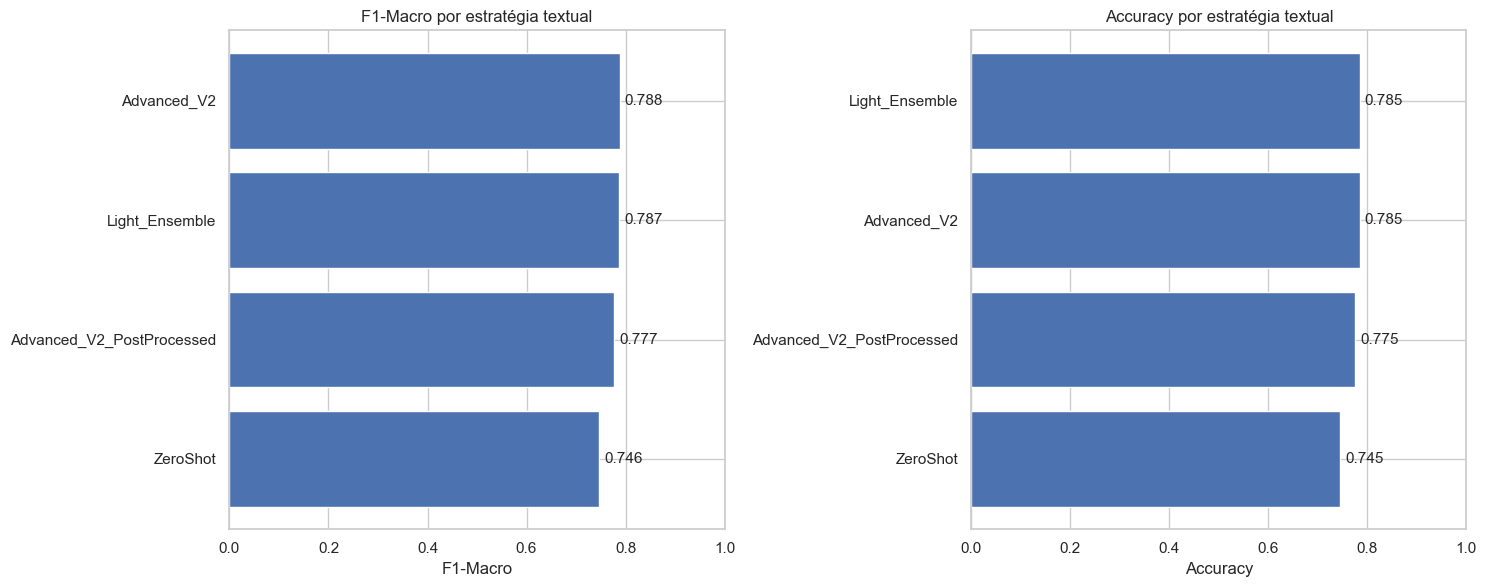

In [ ]:
# ============================================================
# 10. Visualização dos resultados textuais
# ============================================================

plot_df = summary_df.copy()
plot_df["model_strategy"] = plot_df["model"] + " | " + plot_df["strategy"]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

f1_df = plot_df.sort_values("f1_macro", ascending=True)
axes[0].barh(f1_df["model_strategy"], f1_df["f1_macro"])
axes[0].set_title("F1-Macro por modelo + estratégia")
axes[0].set_xlabel("F1-Macro")
axes[0].set_xlim(0, 1)
for i, v in enumerate(f1_df["f1_macro"]):
    axes[0].text(min(v + 0.01, 0.98), i, f"{v:.3f}", va="center")

acc_df = plot_df.sort_values("accuracy", ascending=True)
axes[1].barh(acc_df["model_strategy"], acc_df["accuracy"])
axes[1].set_title("Accuracy por modelo + estratégia")
axes[1].set_xlabel("Accuracy")
axes[1].set_xlim(0, 1)
for i, v in enumerate(acc_df["accuracy"]):
    axes[1].text(min(v + 0.01, 0.98), i, f"{v:.3f}", va="center")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ollama_text_strategy_model_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()

# Visualização focada nos 50 ambíguos
ambiguous_plot_df = difficulty_summary_df[difficulty_summary_df["difficulty"] == "ambiguous"].copy()
if len(ambiguous_plot_df):
    ambiguous_plot_df["model_strategy"] = ambiguous_plot_df["model"] + " | " + ambiguous_plot_df["strategy"]
    ambiguous_plot_df = ambiguous_plot_df.sort_values("f1_macro", ascending=True)

    plt.figure(figsize=(14, 7))
    plt.barh(ambiguous_plot_df["model_strategy"], ambiguous_plot_df["f1_macro"])
    plt.title("F1-Macro apenas nos 50 exemplos ambíguos")
    plt.xlabel("F1-Macro")
    plt.xlim(0, 1)
    for i, v in enumerate(ambiguous_plot_df["f1_macro"]):
        plt.text(min(v + 0.01, 0.98), i, f"{v:.3f}", va="center")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "ollama_text_ambiguous_subset_benchmark.png", dpi=150, bbox_inches="tight")
    plt.show()


In [ ]:
# ============================================================
# 11. Seleção da combinação final modelo + estratégia
# ============================================================
# Regra desta versão:
# - Como o foco é qualidade, escolher a combinação com melhor F1-Macro geral.
# - Em caso de empate muito próximo, considerar também desempenho nos exemplos ambíguos.

summary_ranked = summary_df.sort_values(["f1_macro", "accuracy", "top2_accuracy"], ascending=False).reset_index(drop=True)
best_auto = summary_ranked.iloc[0]

FINAL_TEXT_MODEL = best_auto["model"]
FINAL_TEXT_STRATEGY = best_auto["strategy"]
best_auto_f1 = float(best_auto["f1_macro"])

# Se existir empate até 0.005 F1, desempatar pelo F1 nos exemplos ambíguos.
near_best = summary_ranked[summary_ranked["f1_macro"] >= best_auto_f1 - 0.005].copy()
if len(near_best) > 1:
    amb = difficulty_summary_df[difficulty_summary_df["difficulty"] == "ambiguous"][
        ["model", "strategy", "f1_macro", "accuracy", "top2_accuracy"]
    ].rename(columns={
        "f1_macro": "ambiguous_f1_macro",
        "accuracy": "ambiguous_accuracy",
        "top2_accuracy": "ambiguous_top2_accuracy",
    })
    near_best = near_best.merge(amb, on=["model", "strategy"], how="left")
    near_best = near_best.sort_values(
        ["ambiguous_f1_macro", "f1_macro", "accuracy", "top2_accuracy"],
        ascending=False,
    ).reset_index(drop=True)
    best_auto = near_best.iloc[0]
    FINAL_TEXT_MODEL = best_auto["model"]
    FINAL_TEXT_STRATEGY = best_auto["strategy"]

selection_reason = (
    f"{FINAL_TEXT_MODEL} + {FINAL_TEXT_STRATEGY} escolhido por melhor qualidade: "
    f"F1-Macro geral={float(best_auto['f1_macro']):.3f}, "
    f"Accuracy={float(best_auto['accuracy']):.3f}."
)

final_summary_row = summary_df[
    (summary_df["model"] == FINAL_TEXT_MODEL) &
    (summary_df["strategy"] == FINAL_TEXT_STRATEGY)
].iloc[0]

print("✅ Estratégia final:", FINAL_TEXT_STRATEGY)
print("✅ Modelo final:", FINAL_TEXT_MODEL)
print("📌 Motivo:", selection_reason)
display(pd.DataFrame([final_summary_row]))


🎯 ESTRATÉGIA TEXTUAL FINAL
Modelo: qwen2.5:3b-instruct
Estratégia selecionada: Advanced_V2
Motivo: Advanced_V2 escolhido: está a <=0.03 F1 do melhor e é mais simples/rápido. F1=0.788.
Accuracy:          0.785
Balanced Accuracy: 0.784
F1-Macro:          0.788
Top-2 Accuracy:    0.790


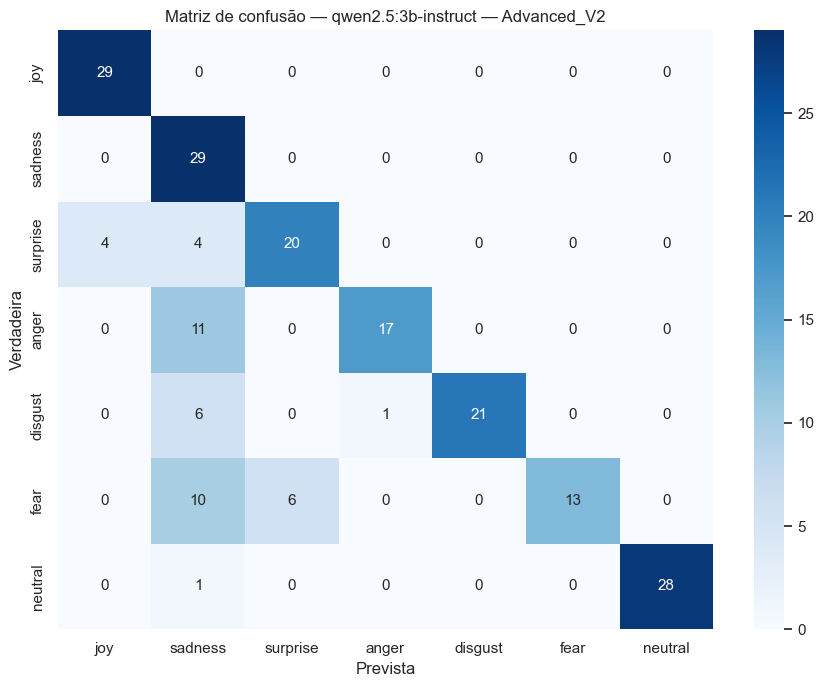

,precision,recall,f1-score,support
joy,0.878788,1.000000,0.935484,29.0
sadness,0.475410,1.000000,0.644444,29.0
surprise,0.769231,0.714286,0.740741,28.0
anger,0.944444,0.607143,0.739130,28.0
disgust,1.000000,0.750000,0.857143,28.0
fear,1.000000,0.448276,0.619048,29.0
neutral,1.000000,0.965517,0.982456,29.0


In [ ]:
# ============================================================
# 12. Matriz de confusão e métricas por emoção da combinação final
# ============================================================

final_results = df_results[
    (df_results["model"] == FINAL_TEXT_MODEL) &
    (df_results["strategy"] == FINAL_TEXT_STRATEGY)
].copy()

y_true = final_results["true_label"]
y_pred = final_results["predicted_label"]

cm = confusion_matrix(y_true, y_pred, labels=EMOTIONS)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=EMOTIONS, yticklabels=EMOTIONS)
plt.title(f"Matriz de confusão — {FINAL_TEXT_MODEL} — {FINAL_TEXT_STRATEGY}")
plt.xlabel("Prevista")
plt.ylabel("Verdadeira")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ollama_text_final_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

report = classification_report(
    y_true,
    y_pred,
    labels=EMOTIONS,
    target_names=EMOTIONS,
    zero_division=0,
    output_dict=True,
)
report_df = pd.DataFrame(report).T
report_df.to_csv(OUTPUT_DIR / "ollama_text_final_classification_report.csv")

print("📄 Classification report final")
display(report_df)

# Report separado para os 50 exemplos ambíguos
ambiguous_final_results = final_results[final_results["difficulty"] == "ambiguous"].copy()
if len(ambiguous_final_results):
    ambiguous_report = classification_report(
        ambiguous_final_results["true_label"],
        ambiguous_final_results["predicted_label"],
        labels=EMOTIONS,
        target_names=EMOTIONS,
        zero_division=0,
        output_dict=True,
    )
    ambiguous_report_df = pd.DataFrame(ambiguous_report).T
    ambiguous_report_df.to_csv(OUTPUT_DIR / "ollama_text_final_ambiguous_classification_report.csv")

    print("📄 Classification report — apenas exemplos ambíguos")
    display(ambiguous_report_df)


,threshold,accepted_n,review_n,coverage,review_rate,accepted_accuracy
0,0.30,200,0,1.000,0.000,0.785000
1,0.35,200,0,1.000,0.000,0.785000
2,0.40,200,0,1.000,0.000,0.785000
3,0.45,199,1,0.995,0.005,0.788945
4,0.50,197,3,0.985,0.015,0.786802
5,0.55,197,3,0.985,0.015,0.786802
6,0.60,197,3,0.985,0.015,0.786802
7,0.65,197,3,0.985,0.015,0.786802
8,0.70,197,3,0.985,0.015,0.786802
9,0.75,195,5,0.975,0.025,0.784615


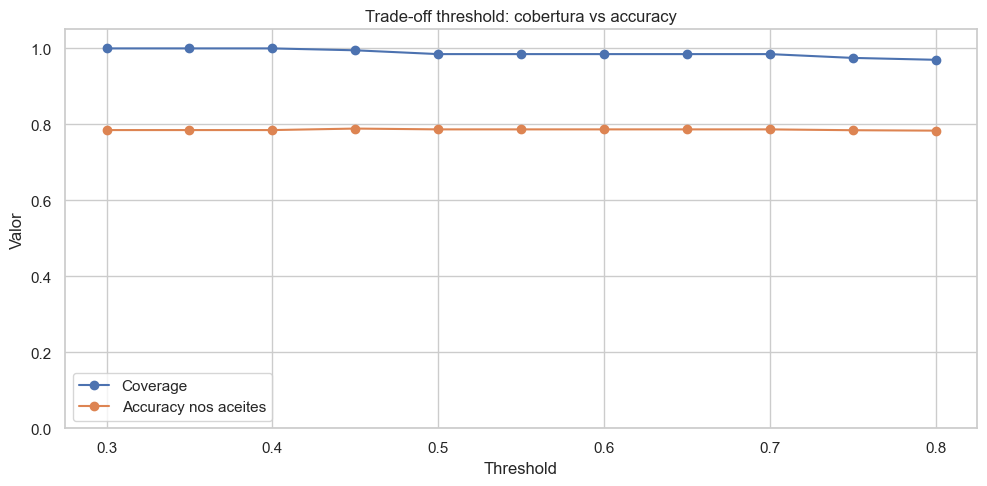

In [ ]:
# ============================================================
# 13. Análise de threshold de confiança
# ============================================================
# Serve para decidir quando enviar uma classificação para revisão humana.
# Em produção, isto ajuda a não forçar uma emoção quando o modelo está incerto.

threshold_rows = []
for threshold in np.arange(0.30, 0.81, 0.05):
    accepted = final_results[final_results["confidence"] >= threshold]
    review = final_results[final_results["confidence"] < threshold]
    acc_accepted = accepted["correct"].mean() if len(accepted) else np.nan
    threshold_rows.append({
        "threshold": round(float(threshold), 2),
        "accepted_n": len(accepted),
        "review_n": len(review),
        "coverage": len(accepted) / len(final_results),
        "review_rate": len(review) / len(final_results),
        "accepted_accuracy": acc_accepted,
    })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df.to_csv(OUTPUT_DIR / "ollama_text_threshold_analysis.csv", index=False)

display(threshold_df)

plt.figure(figsize=(10, 5))
plt.plot(threshold_df["threshold"], threshold_df["coverage"], marker="o", label="Coverage")
plt.plot(threshold_df["threshold"], threshold_df["accepted_accuracy"], marker="o", label="Accuracy nos aceites")
plt.xlabel("Threshold")
plt.ylabel("Valor")
plt.title("Trade-off threshold: cobertura vs accuracy")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ollama_text_threshold_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# 14. Função final de produção para texto
# ============================================================

CONFIDENCE_THRESHOLD = 0.50


def classify_text_emotion(
    text: str,
    model_name: str = FINAL_TEXT_MODEL,
    strategy: str = FINAL_TEXT_STRATEGY,
    confidence_threshold: float = CONFIDENCE_THRESHOLD,
) -> Dict:
    if strategy not in STRATEGIES:
        raise ValueError(f"Estratégia desconhecida: {strategy}. Opções: {list(STRATEGIES)}")

    dist = STRATEGIES[strategy](text, model_name)
    dist = normalize_distribution(dist)
    emotion = max(dist, key=dist.get)
    confidence = float(dist[emotion])

    return {
        "emotion": emotion,
        "confidence": confidence,
        "distribution": dist,
        "needs_review": confidence < confidence_threshold,
        "model_name": model_name,
        "strategy": strategy,
    }

# Exemplo rápido
example = "Hoje foi um dia normal, trabalhei, jantei e fui dormir."
print(classify_text_emotion(example))


{'emotion': 'neutral', 'confidence': 0.8675078864353313, 'distribution': {'joy': 0.022082018927444796, 'sadness': 0.022082018927444796, 'surprise': 0.022082018927444796, 'anger': 0.022082018927444796, 'disgust': 0.022082018927444796, 'fear': 0.022082018927444796, 'neutral': 0.8675078864353313}, 'needs_review': False, 'model_name': 'qwen2.5:3b-instruct', 'strategy': 'Advanced_V2'}


In [ ]:
# ============================================================
# 15. Guardar configuração final
# ============================================================

final_config = {
    "text_models_tested": TEXT_MODELS,
    "final_model_name": FINAL_TEXT_MODEL,
    "selected_strategy": FINAL_TEXT_STRATEGY,
    "selection_reason": selection_reason,
    "confidence_threshold": CONFIDENCE_THRESHOLD,
    "emotions": EMOTIONS,
    "dataset": {
        "total_examples": int(len(df_dataset)),
        "clean_examples": int((df_dataset["difficulty"] == "clean").sum()),
        "ambiguous_examples": int((df_dataset["difficulty"] == "ambiguous").sum()),
        "last_50_are_ambiguous": bool(df_dataset.tail(50)["difficulty"].eq("ambiguous").all()),
    },
    "metrics": final_summary_row.to_dict(),
    "results_file": str(results_path),
    "summary_file": str(summary_path),
    "difficulty_summary_file": str(difficulty_summary_path),
}

with open(OUTPUT_DIR / "ollama_text_final_config.json", "w", encoding="utf-8") as f:
    json.dump(final_config, f, ensure_ascii=False, indent=2)

print("✅ Configuração final guardada em:", OUTPUT_DIR / "ollama_text_final_config.json")
print(json.dumps(final_config, ensure_ascii=False, indent=2))


✅ Configuração final guardada em: ollama_text_outputs/ollama_text_final_config.json
{
  "model_name": "qwen2.5:3b-instruct",
  "selected_strategy": "Advanced_V2",
  "selection_reason": "Advanced_V2 escolhido: está a <=0.03 F1 do melhor e é mais simples/rápido. F1=0.788.",
  "confidence_threshold": 0.5,
  "emotions": [
    "joy",
    "sadness",
    "surprise",
    "anger",
    "disgust",
    "fear",
    "neutral"
  ],
  "metrics": {
    "strategy": "Advanced_V2",
    "accuracy": 0.785,
    "balanced_accuracy": 0.7836030964109783,
    "f1_macro": 0.7883494439252698,
    "f1_weighted": 0.7884896154208179,
    "top2_accuracy": 0.79,
    "n": 200,
    "mean_confidence": 0.8614300150412757
  },
  "results_file": "ollama_text_outputs/ollama_text_benchmark_results.csv",
  "summary_file": "ollama_text_outputs/ollama_text_benchmark_summary.csv"
}


In [ ]:
# ============================================================
# 16. Função de fusão multimodal recomendada
# ============================================================
# Para combinar com o resultado da prosódia.


def _entropy_confidence(dist: Dict[str, float], emotions: List[str] = EMOTIONS) -> float:
    probs = np.array([float(dist.get(e, 0.0)) for e in emotions], dtype=float)
    probs = probs / (probs.sum() + 1e-12)
    probs = np.clip(probs, 1e-12, 1.0)
    entropy = -np.sum(probs * np.log(probs))
    max_entropy = np.log(len(emotions))
    return float(1.0 - entropy / max_entropy)


def fuse_text_audio_emotions(
    text_distribution: Dict[str, float],
    audio_distribution: Dict[str, float],
    text_weight: float = 0.70,
    audio_weight: float = 0.30,
    adaptive: bool = True,
    min_text_weight: float = 0.55,
    max_text_weight: float = 0.85,
) -> Dict[str, float]:
    if adaptive:
        text_conf = _entropy_confidence(text_distribution)
        audio_conf = _entropy_confidence(audio_distribution)
        text_weight = text_weight * (0.75 + 0.5 * text_conf)
        audio_weight = audio_weight * (0.75 + 0.5 * audio_conf)
        s = text_weight + audio_weight
        text_weight, audio_weight = text_weight / s, audio_weight / s
        text_weight = min(max(text_weight, min_text_weight), max_text_weight)
        audio_weight = 1.0 - text_weight

    final = {}
    for emo in EMOTIONS:
        final[emo] = text_weight * float(text_distribution.get(emo, 0.0)) + audio_weight * float(audio_distribution.get(emo, 0.0))
    total = sum(final.values())
    return {k: v / (total + 1e-12) for k, v in final.items()}

print("✅ Função de late fusion pronta.")

✅ Função de late fusion pronta.


## Conclusão deste notebook

A saída mais importante para o trabalho final é:

- `ollama_text_final_config.json` — modelo textual e estratégia escolhida;
- `ollama_text_benchmark_summary_250_multi_model.csv` — comparação de estratégias e modelos;
- `ollama_text_benchmark_summary_by_difficulty.csv` — comparação separada entre exemplos limpos e ambíguos;
- `ollama_text_final_classification_report.csv` — métricas por emoção da combinação final;
- `ollama_text_final_ambiguous_classification_report.csv` — métricas apenas nos 50 casos ambíguos;
- `classify_text_emotion(text)` — função final de produção.

Formulação recomendada para o relatório:

> A modalidade textual foi processada por um LLM local via Ollama, comparando um modelo-base (`qwen2.5:3b-instruct`) com um modelo maior (`qwen2.5:7b-instruct`). A avaliação foi realizada sobre um benchmark textual de 250 relatos em português, incluindo 50 casos finais mais ambíguos e realistas, desenhados para aproximar relatos diários transcritos. A combinação final de modelo e estratégia de prompting foi escolhida com base no F1-Macro, considerando também o desempenho nos casos ambíguos. A saída textual é posteriormente combinada com a distribuição acústica por late fusion.

Nota metodológica: estes textos continuam a ser um benchmark controlado. Para o relatório, a melhoria importante é dizer que o conjunto já inclui casos ambíguos e realistas, mas que uma validação final ideal poderá usar relatos reais anotados manualmente quando houver recolha de dados suficiente.
